# Table of Contents

1. [Problem introduction](#1-problem-introduction)
    1. [Literature review](#11-literature-review)
1. [Model description](#2-model-formulation)
    1. [Mathematical formulation](#21-mathematical-formulation)
    1. [Modelling code](#22-modelling-code)
1. [Dataset creation](#3-dataset-creation)
    1. [Arc profitability](31-#arc-profitability)
    1. [Matching GPS locations to OSM nodes](#32-matching-gps-locations-to-osm-nodes)
    1. [Calculating profit and penalty](#33-calculating-profit-and-penalty)
        1. [Defining profit and historic penalty](#331-defining-profit-and-historic-penalty)
        1. [Defining current penalty](#332-defining-current-penalty)
        1. [Final coefficient calculations](#333-final-coefficient-calculations)
    1. [Dataset creation code](#34-dataset-creation-code)
        1. [Runtrack](#341-runtrack)
        1. [Instance creation](#342-instance-creation)
        1. [Example use](#343-example-use)
1. [Instances](#4-instances)
    1. [Graph sizes](#41-graph-sizes)
    1. [Run lengths](#42-run-lengths)
1. [Results](#5-results)
    1. [Experimental setup](#51-experimental-setup)
    1. [Experimental results](#52-experimental-results)
1. [Improvements](#6-improvements)
    1. [Interior node removal](#61-interior-node-removal)
    1. [Branch-and-bound adjustments](#62-branch-and-bound-adjustments)
        1. [Penalizing the lower bound constraint](#621-penalizing-the-lower-bound-constraint)
        1. [Lower bound heuristic](#622-lower-bound-heuristic)
        1. [Branching strategy and priority](#623-branching-strategy-and-priority)
    1. [Experimental results](#63-experimental-results)
1. [Conclusion](#7-conclusion)

# i. Preamble

## i.i Required Packages

The following packages are required for the code to run.

<div class="alert alert-block alert-danger">
<b>To do:</b> Convert back to python
</div

%pip install contextily
%pip install garmin-fit-sdk
%pip install geopandas
%pip install gpxpy
%pip install matplotlib
%pip install networkx
%pip install numpy
%pip install osmnx
%pip install pandas
%pip install requests
%pip install scipy
%pip install seaborn
%pip install shapely
%pip install sklearn

## i.ii Imports

In [14]:
import io
import itertools
import math
import os
import pickle
import warnings

from collections import deque, defaultdict
from dataclasses import dataclass

from time import time
from tqdm import tqdm

import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.signal import find_peaks

import pandas as pd
import geopandas as gpd
import shapely as sp
import contextily as cx

import networkx as nx
import osmnx as ox

import requests
from garmin_fit_sdk import Decoder as gfDecoder, Stream as gfStream
import gpxpy

from sklearn.neighbors import BallTree

# MIP Modeling
import gurobipy as gp
from gurobipy import GRB

from PIL import Image
from io import BytesIO

## i.iii Constants & Settings

In [15]:
INSTANCE_DIRECTORY = "instances"

EARTH_RADIUS_M = 6_371_009  # distance in meters
GAR_ANGLE_SCALER = 2**32 / 360

SIGMA_Z = 4.07
BETA = 3

ox.settings.bidirectional_network_types = ["walk", "drive", "all"]
sns.set_theme(style="white")

# 1. Problem introduction

Running long distances is the kind of hobby where monotony can set in for even its most ardent devotees, particularly in urban areas where there may not be much in the way of scenery. In an effort to mitigate potential boredom, many runners seek out new routes, which has become a hobby in itself with apps like CityStrides [[2]](#citystrides) and Wandrer [[9]](#wandrer). While these apps track which streets in a particular city have been previously run, they lack the functionality to use that information to generate new routes that traverse as-yet-unvisited streets.

This project aims to fill that gap, by developing an integer linear program (ILP) that maximizes the number of new streets run while minimizing the number of repeated streets. We call this the running route problem (RRP). The rest of this report is divided as follows. We begin with a (very) brief literature review in the remainder of this section. Section 2 provides the model formulation, while sections 3 and 4 cover the dataset creation process and description of our problem instances, respectively. In section 5, we discuss the results of our base model. Section 6 is devoted to discussion of our approaches to efficiency improvement. Finally, in section 7, we provide concluding remarks.

## 1.1 Literature Review

Fundamentally, The RRP is a combinatorial graph-traversal problem and as such is related to the great body of literature consisting of generalizations and variants of the travelling salesman problem. More specifically, it shares characteristics with two different strains of problems from this area: orienteering problems and arc-routing problems.

Orienteering problems are a combination of node selection and shortest path problems, in which each node has an associated profit and each edge has an associated cost. The goal is to leave the depot, collect as much profit as possible, and return to the depot within a specified budget [[6](#orienteering)]. Meanwhile, arc-routing problems are a variant of standard routing problems where, rather than servicing the nodes of a graph, the service is performed on the edges [[4](#arcrouting)].

Therefore, the RRP can be considered a variant of the orienteering arc-routing problem (OARP) as defined by Archetti et al. [[1](#oarp)], with two notable differences:
1. The OARP has arcs that must be serviced, while the RRP has no such required arcs; and,
2. The RRP includes a penalty for revisting arcs, while the OARP does not.

As will be seen, these two differences have a significant impact on the tractability of the problem and efficiency of various heuristics and cuts.

# 2. Model description

Let $G(V, A)$ denote a directed graph with vertices $V$ and arcs $A$. Each arc $a \in A$ has an associated profit, $s_{ij}$, historic penalty $q_{ij}$, current penalty, $p_{ij}$, and length, $c_{ij}$. The profit of an arc is derived from the CityStrides data and the penalties are derived from the visited count of that particular arc. Choosing to run an arc will incurr a cost comprising of its profit and penalties. The final route must form a tour, where the solution must start and end at the depot, and must not contain any subtours. The total distance must be within 80%-100% of the user-defined desired run length. The objective is to maximize the total profit incurred by a tour. 


## 2.2 Mathematical formulation

The decision variables are $x_{ij}, y_{ij}$ and $z_{ij}$, and are defined below: 

\begin{align*}
    x_{ij} = \text{Number of times arc $(i,j)$ is ran}
\end{align*}

\begin{align*}
y_{ij} = 
\begin{cases}
1 & \text{if arc $(i,j)$ is chosen to be ran}  \\
0 & \text{otherwise }
\end{cases}
\end{align*}

\begin{align*}
    z_{ij} = 
    \begin{cases}
    1 & \text{if either arc $(i,j)$ or arc $(j,i)$ is chosen to be ran}  \\
    0 & \text{otherwise }
    \end{cases}
\end{align*}

The variables $x_{ij}$ and $y_{ij}$ are used to define choosing an arc $(i,j)$ to be ran. The variable $z_{ij}$ is used to determine the profit of an arc. The profit of running a particular arc is independent of the direction, ie. running an arc $(i,j)$ from $i$ to $j$ should incur the same profit as $j$ to $i$ and should only be incurred once if both directions are ran. Therefore, the variable $z_{ij}$ ensures that if we run an arc $(i,j)$ at least once in either direction, we incur the profit of the arc. 

The full model formulation is presented below:

\begin{align*}
    \max & \sum_{(i,j)\in A} s_{ij}z_{ij} - q_{ij}y_{ij} -p_{ij}x_{ij} && \tag{1.1}\\
    \text{s.t.} &  \sum\limits_{j \in V\setminus i} x_{ij}  = \sum\limits_{j \in V\setminus i} x_{ji} && \forall i \in V & \tag{1.2}\\
    & z_{ij} \geq y_{ij} && \forall (i,j) \in A, i\leq\ j & \tag{1.3}\\
    & z_{ij} \geq y_{ji} && \forall (i,j) \in A, i\leq j & \tag{1.4}\\
    & y_{ij} + y_{ji} \geq z_{ij} && \forall (i,j) \in A, i\leq j & \tag{1.5}\\
    & \sum\limits_{i \in V\setminus S, j \in S} x_{ij} \geq y_{kl} && \forall S \subset V\setminus \{0\},  \forall(k,l) \in A(S) & \tag{1.6}\\
    & x_{ij} \geq y_{ij} && \forall (i,j) \in A & \tag{1.7}\\
    & y_{ij}\cdot 2 \geq x_{ij} && \forall (i,j) \in A &\tag{1.8} \\
    & \sum\limits_{(i,j) \in A} c_{ij}x_{ij} \leq T_{max} & \tag{1.9}\\
    & \sum\limits_{(i,j) \in A} c_{ij}x_{ij} \geq 0.8\cdot T_{max} & \tag{1.10}\\
    & \sum\limits_{j\in A(0)} y_{0j} \geq 1 & \tag{1.11}\\
    & x_{ij} \in \mathbb{N} && \forall (i,j) \in A & \tag{1.12}\\
    & y_{ij} \in \{0,1\} && \forall (i,j) \in A & \tag{1.13}\\
    & z_{ij} \in \{0,1\} && \forall (i,j) \in A, i<j & \tag{1.14}\\
\end{align*}

The Objective function (1.1) defines the total profit of a run and is accumulated from the profit of running new arcs minus the historic and current penalty from running arcs that have already been ran. Constraint (1.2) is the symmetry constraint which ensure flow conservation at each node. The set of Constraints (1.3-1.5) reflect the bi-conditional relationship between the variables $y_{ij}$ and $z_{ij}$, where the variable $z_{ij}$ must be 1 if either $y_{ij}$ or $y_{ji}$ is 1, and 0 otherwise. Subtours are eliminated by Constraint (1.6), where $S$ denotes any tour that does not contain the depot 0 and therefore must be a subtour. The constraint eliminates these subtours by ensuring that for all edges in the subtour $y \in S$, you must enter the subtour at least once using edges between nodes that are in the subtour, $j \in S$, and the nodes that are not in the subtour, $i \in S$. Constraints (1.7-1.8) reflect the bi-conditional relationship between the variables $x_{ij}$ and $y_{ij}$ where $y_{ij}=1$ if $x_{ij}>=1$ and vice versa. The total length is reflected in the Constraints (1.9-1.10) where the total distance ran must be less than the maximimum $T_{max}$ but more than 80% of $T_{max}$. The second constraint of these two was added to ensure that the final route is still close to our desired run length. Without it, the model can return a short route that maximimizes the profit by not running edges that have been already ran. Finally, Constraint (1.11) ensures that we start at the depot, which is node 0, by forcing the model to leave the depot at least once. 

## 2.2 Modelling code

In [ ]:
def subtourelim(model, where):
    if where == GRB.Callback.MIPNODE:
        # Get results
        time = model.cbGet(GRB.Callback.RUNTIME)
        obj = model.cbGet(GRB.Callback.MIPNODE_OBJBST)
        bound = model.cbGet(GRB.Callback.MIPNODE_OBJBND)
        node_count = model.cbGet(GRB.Callback.MIPNODE_NODCNT)

        model._data.append((time, obj, bound, node_count))

    if where == GRB.Callback.MIPSOL:
        solution_x = model.cbGetSolution(model._x)
        solution_y = model.cbGetSolution(model._y)

        ## Subtour elimination
        # Identify visited nodes
        visited_edges = [edge for edge in model._edges if solution_x[edge] > 0.05]
        visited_nodes = set()
        for edge in visited_edges:
            i, j = edge
            visited_nodes.update({i, j})

        # Define graph of subtours
        S = nx.Graph()
        for i in visited_nodes:
            for j in visited_nodes:
                if (i, j) in model._edges:
                    if i != j and solution_x[(i, j)] > 0.05:
                        S.add_edge(i, j)

        # Find connected components (subtours)
        components = list(nx.connected_components(S))

        # Add subtour elimination constraints for each disconnected component
        for subtour in components:
            if model._depot in subtour:
                continue

            expr_arc = gp.quicksum(
                model._x[i, j]
                for i in subtour
                for j in subtour
                if i != j and (i, j) in model._edges
            )
            model.cbLazy((expr_arc <= len(subtour) - 1))


def solve_MIP(C, total_length, start_node_no, time_limit):
    C = nx.DiGraph(C)

    # Get visited, profit, and penalty
    visited = {edge: C.edges[edge]["visited"] for edge in C.edges}
    profit = {edge: C.edges[edge]["profit"] for edge in C.edges}
    penalty = {edge: C.edges[edge]["penalty"] for edge in C.edges}

    edges, lengths = gp.multidict({edge: C.edges[edge]["length"] for edge in C.edges})
    nodes = C.nodes
    # node_dict = {i:{j for _, j in edges if _ == i } for i in nodes} # Dictionary of connected nodes, old really slow

    node_dict = defaultdict(set)
    for i, j in edges:
        node_dict[i].add(j)

    # Build model

    m = gp.Model("mp")
    print("building model...")

    # Variables
    print("adding variables...")
    x = m.addVars(
        edges, name="traversed", vtype=GRB.INTEGER
    )  # number of times arc (i,j) is traversed
    y = m.addVars(
        edges, name="run", vtype=GRB.BINARY
    )  # arc (i,j) is chosen to be ran, {0,1}

    z = m.addVars(
        {(i, j) for i, j in edges if i < j}, name="profitable_route", vtype=GRB.BINARY
    )

    ## Constraints
    print("adding constraints...")

    # Symmetry Constraint
    symm = m.addConstrs(
        (x.sum(i, "*") == x.sum("*", i) for i in node_dict), name="symmetry"
    )

    # Connectivity Constraint (bi-conditional)
    conn1_const = m.addConstrs(
        (
            x[i, j] >= y[i, j]
            for i in nodes
            for j in nodes
            if i != j and j in node_dict[i]
        )
    )
    conn2_const = m.addConstrs(
        (
            y[i, j] * 2 >= x[i, j]
            for i in nodes
            for j in nodes
            if i != j and j in node_dict[i]
        )
    )

    # Total Length Constraint
    max_length_const = m.addConstr(
        (x.prod(lengths) <= total_length), name="total_length"
    )
    min_length_const = m.addConstr(
        (x.prod(lengths) >= total_length * 0.8), name="total_length"
    )

    # Start at start node
    start_node = m.addConstrs(
        (y.sum(start_node_no, j) >= 1 for j in node_dict[start_node_no]),
        name="start_node",
    )  ## this crashes the model, makes it infeasible

    # Set only one route as profitable

    profit_1 = m.addConstrs(
        (z[i, j] >= y[i, j] for i in nodes for j in nodes if i <= j and (i, j) in edges)
    )
    profit_2 = m.addConstrs(
        (z[i, j] >= y[j, i] for i in nodes for j in nodes if i <= j and (i, j) in edges)
    )
    profit_3 = m.addConstrs(
        (
            y[i, j] + y[j, i] >= z[i, j]
            for i in nodes
            for j in nodes
            if i <= j and (i, j) in edges
        )
    )

    print("add objective function...")
    m.setObjective(z.prod(profit) - y.prod(penalty) - x.prod(visited), GRB.MAXIMIZE)

    # Set-up lazy constraints and call variables
    m.Params.LazyConstraints = 1
    m._x = x
    m._y = y
    m._z = z
    m._edges = edges
    m._N = nodes
    m._data = []
    m._depot = start_node_no
    m.setParam("TimeLimit", time_limit)
    m.setParam("LogtoConsole", 0)
    m.setParam("LogFile", f"baseline_{instance}_{total_length}.log")

    print("start solving model...")
    m.optimize(subtourelim)

    ## Recording solution data
    # Add last solution data
    node_count = m.NodeCount
    obj = m.ObjVal
    bound = m.ObjBound
    time = m.Runtime
    m._data.append((time, obj, bound, node_count))

    # Record results
    with open(log_filename + ".csv", "w") as f:
        for sol_data in m._data:
            time, obj, bound, node_count = sol_data

            f.write("{}, {}, {}, {}\n".format(time, obj, bound, node_count))

    # If model found a feasible solution in the time limit
    if m.solCount > 0:
        # Draw final graph
        F = nx.DiGraph()

        for i in nodes:
            for j in nodes:
                if (i, j) in edges:
                    if x[(i, j)].x >= 0.05:
                        F.add_edge(i, j, visited=float(x[(i, j)].x))

        # pos = nx.spring_layout(F)
        # plt.figure()
        # nx.draw(F, pos, with_labels=True, node_color='lightblue', edge_color='gray', arrows=True)
        # plt.title("Optimal Run")
        # plt.show()

        # Create final graph solution
        print("saving graphs to file", end=" ", flush=True)

        log_filepath = "final_test/"

        with open(
            log_filepath + "sol_graph_" + instance + "_" + str(total_length) + ".pkl",
            "wb",
        ) as file:
            pickle.dump(F, file, pickle.HIGHEST_PROTOCOL)

    print("complete!")


# Parameters
total_length_lst = [5000, 10000, 15000]
instance_lst = ["instance-jess-min", "instance-jess", "instance-jin"]

time_limit = 1800

for instance in instance_lst:
    for total_length in total_length_lst:
        if "jess" in instance:
            start_node_no = 6813225352

        if "jin" in instance:
            start_node_no = 394502562

        log_filepath = "final_test/"
        log_filename = log_filepath + instance + "_" + str(total_length)

        print("reading instance file...")

        C = pd.read_pickle(instance + ".pkl")

        C = ox.truncate.truncate_graph_dist(C, start_node_no, total_length)

        # Run experiments
        print("running experiment with " + str(total_length) + " total_length")
        solve_MIP(C, total_length, start_node_no, time_limit)

# 3. Dataset creation

As mentioned, the input data for the model includes the following items:

* $G = (V,A)$, a directed graph with vertex set $V$ and arc set $A$
* For each arc $(i,j) \in A$:
    * $s_{ij}$, the profit of the arc,
    * $q_{ij}$, the historic penalty of the arc,
    * $p_{ij}$, the current penalty of the arc,
    * $c_{ij}$, the cost (length) of the arc.

As it turns out, creating this input from an individual's running history as captured by Strava is non-trivial. In brief, the process is:

1. Generate the graph of the city to be run from OpenStreetMap (OSM), including the length of each arc $c_{ij}$.
1. Partition $A$ into unprofitable arcs and potentially-profitable arcs.
1. For each activity in the individual's Strava history:
    1. Discard the activity if it contains no location data.
    1. Discard the activity if none of the activity's GPS locations fall within the city's bounds.
    1. Map the activity's GPS locations to nodes in $V$ to create a walk $W$.
1. Use this set of walks to calculate the number of times each arc $(i,j) \in A$ has been traversed previously.
1. From the visit counts and the graph partition, determine the profit, historic penalty, and current penalty for each arc.

Sections 3.1 to 3.3 describe this process in more detail, while section 3.4 includes the implementation.

## 3.1 Arc profitability

OpenStreetMap uses the concept of *ways* to describe linear features - that is, streets, paths, walls, etc [[10](#way)]. Not every street is runnable, and not every runnable way is a street. Fortunately, CityStrides publishes the OSM query used to generate the app's list of runnable streets. [[7](#osmbasics),[3](#csquery)] Therefore, we partition $A$ into two sets:
* The set of *unprofitable* arcs is those arcs which are runnable as defined by OSM tags, but not included in the CityStrides list of runnable streets.
* The set of *potentially profitable* arcs is the set of arcs in the CityStrides list of runnable streets.
We call the latter set potentially profitable as arcs in this set are only profitable if they have not previously been visited.

## 3.2 Matching GPS locations to OSM nodes

Matching GPS coordinates to OSM nodes is highly non-trivial&mdash;in fact, the general problem of matching a coordinate system to a model of the real world is called map matching, and is well-studied in its own right [[5](#mapmatch)]. We used a modified version of the [PyTrack](https://github.com/cosbidev/PyTrack) library developed by Tortora, Cordelli, and Soda [[8](#pytrack)], which uses a hidden Markov model approach to solve the map matching problem, to efficiently match the GPS locations from hundreds of routes to OSM nodes. Our modifications were focused in two areas: first, to allow matchings between GPS coordinates that are an arbitrary distance from an OSM node, rather than requiring a user-defined range; and second, to modularize the code for improved performance when performing matchings for multiple routes in a similar geographic area. This latter improvement was particularly effective, reducing the time of matching from over three hours to match a single route to the OSM graph of Toronto, to matching 50 routes to the Toronto graph in approximately fifteen minutes.

In order to get such a speedup, we performed some pre-processing on the entire graph at once, rather than repeating the processing for each route. We also restricted the search area for each route, and finally we cached results from each route so we didn't repeat calculations for the same OSM nodes more than once. Importantly, insights from this process were instrumental in developing the most effective efficiency improvements for our ILP model.

## 3.3 Calculating profit and penalty

One of the challenges in defining the objective function for our ILP is that our profit and penalty are readily available from the instance data, as would be the case in a more standard setting&mdash;that is, we have no customer demand, product price, or similar metrics that are easily translatable into objective coefficients. There are, however, some common sense qualities we expect these coefficients to posess, and we can use these qualities to develop a mathematical formulation for these quantities.

First, note that our objective function explicitly trades off between the profit of running unseen edges and the penalty from running edges repeatedly. We start by considering two extreme cases.

**Case 1:** Consider an instance in which only one potentially-profitable arc *has not* been visited. In this scenario, it is more important to traverse that arc than it is to avoid arcs with high penalties, since traversing that arc will "complete" the city.

**Case 2:** Conversely, for an instance in which only one potentially-profitable arc *has* been visited, it is more important to avoid previously-visited arcs. This is because in this scenario, virtually all potentially-profitable arcs are in fact profitable, and we get profit almost "for free", and avoiding repeated arcs is relatively more important in deciding the route.

Extrapolating from these two extreme cases, we can make three observations:

1. Profit should be roughly proportional to the fraction of potentially-profitable arcs we have already visited.
1. Penalty should be roughly *inversely* proportional to the fraction of potentially-profitable arcs we have already visited, and thus inversely proportional to profit.
1. When half of the potentially-profitable arcs have been visited, the general concept of "profit" should be roughly equal to the general concept of "penalty".

Next, we will operationalize these observations.

### 3.3.1 Defining profit and historic penalty

First, notice that all unvistied potentially-profitable arcs are equally valuable. That is,
$$s_{ij} = s$$
for all unvisited potentially-profitable arcs $(i,j)$.

Now, let $vc_{ij}$ be the visit count of arc $(i,j) \in A$, that is the number of times we have previously visited arc $(i,j)$, and let $r$ be the fraction of potentially-profitable arcs with $vc_{ij} > 0$. Then, perhaps the easiest definition for historic penalty is simply
$$q_{ij} = vc_{ij}$$

If we define $q_{\max}$ as the largest historic penalty (ie, $q_{\max} = \max q_{ij}$), then from our observations in the previous section, we can see that 
$$\frac{s}{q_{\max}} \propto \frac{r}{1-r}$$
Note that we use $q_{\max}$ in this formulation since when $r > 1-r$, $s$ should be greater than *any* penalty $q_{ij}$.

Since we are defining $q_{ij}$ based on $vc_{ij}$, it follows that for any visited arc, $q_{ij} \geq 1$. We reason that due to the proportional "symmetry" between $q_{\max}$ and $s$, we should also have $s \geq 1$. (This also helps with numeric stability, by preventing $s$ from being very small when both $r$ and $q_{\max}$ are small.)

Pulling it all together, we define $s$ as
$$s = \max\left\{\frac{r}{1-r}\cdot q_{\max},\ 1\right\}

### 3.3.2 Defining current penalty

Current penalty is a little trickier to define. First, notice that in some sense current penalty is a marginal cost, since it is the cost of the *next* arc traversal, given historic traversals. In other words, it should be both proportional to historic penalty and smaller than it (assuming historic penalty in nonzero). Since the overarching goal is to traverse new arcs, we argue that current penalty should also be smaller than profit. Similar to historic penalty, we define $p_{\max} = \max p_{ij}$. Then we must have
$$p_{\max} < \min\{s,\,q_{\max}\}$$
for all nonzero $s$ and $q_{\max}$. Let $c = \min\{s,\,q_{\max}\}$. Then, since penalty decreases in importance as $r$ increases, we can capture this relationship by setting
$$p_{\max} =  c(1-r)$$

It can be seen that this equality enforces the previous strict inequality, since $p_{\max} = c$ if and only if $r = 0$, or none of the arcs have been traversed, which implies that $q_{\max} = 0$.

As noted previously, when $vc_{ij} > 0$, then both $s \geq 1$ and $q_{\max} \geq 1$. This leads to two cases for $p_{\max}$: $0 \leq p_{\max} \leq 1$ and $p_{\max} > 1$. In the first case, wince $p_{\max}$ is already small, then for both reasonablness and numerical stability, we define
$$p_{ij} = p_{\max}$$
for all $(i,j) \in A$.

In the second case ($p_{\max} > 1$), we want $p_{ij}$ to be monotonically increasing in $q_{ij}$, but since our emprical datasets have both exponential and multi-modal characteristics, a linear increase is not appropriate. Rather, we define a sigmoid function relating the two:
$$p_{ij} = \text{sig}(q_{ij}) = a + b\cdot\frac{q_{ij} - q_m}{\sqrt{(q_{ij}-q_m)^2 + \kappa^2}}$$
where $\kappa$ is a scaling factor equal to twice the standard deviation of $vc$, $a$ and $b$ are constants calculated based on the boundary conditons $\text{sig}(1) = 1$ and $\text{sig}(c(1-r)) = p_{\max}$, and $q_m$ is a "mode" calculated by the following procedure:
1. Transform the dataset into a set of points $VC = (vc,n_{vc})$, where $vc$ is the visit count and $n_{vc}$ is the number of edges with that visit count.
1. Perform weighted kernel density estimation on $VC$ where the weights are $vc$. This increases the importance of high visit counts, even if there aren't many edges with that visit count.
1. Find the peaks of the resulting pdf, which approximate the modes of the dataset. Call the set of these peaks $M = \{m_1,m_1,\ldots,m_n\}$, where $m_i = vc_i$, the location of the peak, and $m_i < m_j$ if and only if $vc_i < vc_j$.
1. Define $q_m$  based on the number of peaks found:
    * If $|M| > 2$, then $q_m = m_2$, the second "mode".
    * If $|M| = 2$, then $q_m = m_1$, the first "mode".
    * If $|M| < 2$, then $q_m = \frac{1}{2}q_{\max}$.

What this procedure does is center the sigmoid at the second mode when there are more than two modes. This is important because the first mode is just going to be at 1 or 2 or some other low value. We're looking for something more in the middle-ish of the distribution, and the second mode seems to find that. If the distribution turns out to be bimodal, then the first mode is selected to avoid most arcs having very low penalties, and if the distribution is unimodal, then we fall back on centering the sigmoid at the midway point of the distribution.

### 3.3.3 Final coefficient calculations

In summary, we set the coefficents as follows:

* $q_{ij} = vc_{ij}$
* $s_{ij} = s = \frac{r}{1-r}\cdot q_{\max}$
* $p_{ij} = \text{sig}(q_{ij}) = a + b\cdot\frac{q_{ij} - q_m}{\sqrt{(q_{ij}-q_m)^2 + \kappa^2}}$
* $c_{ij}$ is the length of the arc as defined by OSM

## 3.4 Dataset creation code

### 3.4.1 Runtrack

This section includes the map matching code, forked from [PyTrack](https://github.com/cosbidev/PyTrack).

In [16]:
def graph_to_gdfs(G, nodes=True, edges=True, node_geometry=True, edge_geometry=True):
    """Convert a networkx.MultiDiGraph to node and/or edge pandas DataFrame.

    Parameters
    ----------
    G: networkx.MultiDiGraph
        Street network graph.
    nodes: bool, optional, default: True
        Whether to extract graph nodes.
    edges: bool, optional, default: True
        Whether to extract graph edges.
    node_geometry: bool, optional, default: True
        Whether to compute graph node geometries.
    edge_geometry: bool, optional, default: True
        Whether to extract graph edge geometries.
    Returns
    -------
    gdf_nodes: pandas.DataFrame
        Dataframe collecting graph nodes.
    gdf_edges: pandas.DataFrame
        Dataframe collecting graph edges
    """
    crs = G.graph["crs"]

    if nodes:
        nodes, data = zip(*G.nodes(data=True))

        if node_geometry:
            # convert node x/y attributes to Points for geometry column
            for d in data:
                d["geometry"] = sp.Point(d["x"], d["y"])
            gdf_nodes = pd.DataFrame(data)
            gdf_nodes.insert(loc=0, column="osmid", value=nodes)
        else:
            gdf_nodes = pd.DataFrame(data)
            gdf_nodes.insert(loc=0, column="osmid", value=nodes)

    if edges:
        u, v, data = zip(*G.edges(data=True))
        if edge_geometry:
            G.graph["geometry"] = True

            longs = G.nodes(data="x")
            lats = G.nodes(data="y")

            for d, src, tgt in zip(data, u, v):
                if "geometry" not in d:
                    d["geometry"] = sp.LineString(
                        (
                            sp.Point((longs[src], lats[src])),
                            sp.Point((longs[tgt], lats[tgt])),
                        )
                    )
            gdf_edges = pd.DataFrame(data)

        else:
            gdf_edges = pd.DataFrame(data)
            gdf_edges["geometry"] = None
            gdf_edges.crs = crs

        gdf_edges["u"], gdf_edges["v"] = u, v

        gdf_edges = gdf_edges[["u", "v"] + gdf_edges.columns.to_list()[:-2]]

    if nodes and edges:
        return gdf_nodes, gdf_edges
    elif nodes:
        return gdf_nodes
    elif edges:
        return gdf_edges


def haversine_dist(lat1, lon1, lat2, lon2):
    """Calculate the great circle distance between two points on the earth (specified in decimal degrees)

    Parameters
    ----------
    lat1: float
        Latitude of the first point specified in decimal degrees
    lon1: float
        Longitude of the first point specified in decimal degrees
    lat2: float
        Latitude of the second point specified in decimal degrees
    lon2: float
        Longitude of the second point specified in decimal degrees

    earth_radius: float, optional, default: 6371009.0 meters
        Earth's radius
    Returns
    ----------
    dist: float
        Distance in units of earth_radius
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # haversine formula
    h = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    h = np.minimum(1, h)  # protect against floating point errors
    arc = 2 * np.arcsin(np.sqrt(h))

    dist = arc * EARTH_RADIUS_M

    return dist


In [17]:
@dataclass
class Candidate:
    node_id: str
    edge_osmid: str
    obs: tuple
    great_dist: float
    coord: tuple


class CandidateHandler:
    __slots__ = ["ball_tree", "coords", "G", "index", "nodes", "nodes_deg", "rtree"]

    def __init__(self, G):
        self.G = G
        geoms = graph_to_gdfs(self.G, nodes=False).set_index(["u", "v"])[
            ["osmid", "geometry"]
        ]

        uv_xy = [
            [u, osmid, np.deg2rad(xy)]
            for uv, geom, osmid in zip(
                geoms.index, geoms.geometry.values, geoms.osmid.values
            )
            for u, xy in zip(uv, geom.coords[:])
        ]

        index, osmid, xy = zip(*uv_xy)
        self.index = np.array(index)

        x, y = zip(*xy)
        self.nodes = gpd.GeoSeries.from_xy(x, y, index=osmid)
        self.nodes_deg = self.nodes.apply(lambda x: sp.transform(x, np.rad2deg))
        self.rtree = self.nodes_deg.sindex
        self.coords = self.nodes.get_coordinates()

        self.ball_tree = BallTree(self.coords, metric="haversine")

        # return index, nodes, nodes_deg, rtree, coords, ball

    def get_candidates(self, df, radius=10):
        """Extract candidate points for Hidden-Markov Model map-matching approach.

        Parameters
        ----------
        G: networkx.MultiDiGraph
            Street network graph.
        points: list
            The actual GPS points.
        interp_dist: float, optional, default: 1
            Step to interpolate the graph. The smaller the interp_dist, the greater the precision and the longer
            the computational time.
        closest: bool, optional, default: True
            If true, only the closest point is considered for each edge.
        radius: float, optional, default: 10
            Radius of the search circle.
        Returns
        -------
        G: networkx.MultiDiGraph
            Street network graph.
        results: dict
            Results to be used for the map-matching algorithm.
        """
        points = [
            (lng, lat)
            for lat, lng in zip(
                df["position_lat"].to_list(), df["position_long"].to_list()
            )
        ]
        idxs, dists = self.ball_tree.query_radius(
            np.deg2rad(points), radius / EARTH_RADIUS_M, return_distance=True
        )
        not_found = [
            [points[i], i] for i, idx_array in enumerate(idxs) if idx_array.size == 0
        ]
        while len(not_found) > 0:
            not_found, nf_i = zip(*not_found)
            radius = radius * 2
            nf_idxs, nf_dists = self.ball_tree.query_radius(
                np.deg2rad(not_found), radius / EARTH_RADIUS_M, return_distance=True
            )
            idxs[list(nf_i)] = nf_idxs
            dists[list(nf_i)] = nf_dists
            not_found = [
                [points[i], i]
                for i, idx_array in enumerate(idxs)
                if idx_array.size == 0
            ]

        dists = dists * EARTH_RADIUS_M  # radians to meters

        results = {
            i: {
                "observation": point,
                "osmid": list(self.index[idx]),
                "edge_osmid": list(self.nodes.index[idx]),
                "candidates": list(map(tuple, np.rad2deg(self.coords.values[idx]))),
                "candidate_type": np.full(len(self.nodes.index[idx]), False),
                "dists": list(dist),
            }
            for i, (point, idx, dist) in enumerate(zip(points, idxs, dists))
        }

        no_cands = [
            node_id for node_id, cand in results.items() if not cand["candidates"]
        ]

        if no_cands:
            for cand in no_cands:
                del results[cand]
            print(
                f"A total of {len(no_cands)} points have no candidates.",
                end=" ",
                flush=True,
            )

        dist = max(
            max(results.values(), key=lambda point: max(point["dists"]))["dists"]
        )  # max distance
        gdf = gpd.GeoDataFrame(
            geometry=[
                sp.MultiPoint(
                    [
                        latlng
                        for point in results.values()
                        for latlng in point["candidates"]
                    ]
                ).convex_hull
            ],
            crs="EPSG:4326",
        )
        gdf = gdf.to_crs(gdf.estimate_utm_crs())
        gdf.geometry.buffer(max(dist * 10, 500))
        gdf = gdf.to_crs("EPSG:4326")

        possible_matches_iloc = self.rtree.query(
            gdf.geometry[0], predicate="intersects"
        )
        possible_matches = self.nodes_deg.iloc[list(possible_matches_iloc)]

        precise_matches = possible_matches[possible_matches.intersects(gdf.geometry[0])]
        to_keep = set(precise_matches.index)

        try:
            to_remove = set(self.index[~self.nodes_deg.index.isin(to_keep)])
            to_keep = set(self.index[self.nodes_deg.index.isin(to_keep)])
        except NameError as err:
            raise ValueError(
                "Found no graph nodes within the requested polygon."
            ) from err

        if len(to_keep) < len(to_remove):
            G_sub = self.G.subgraph(to_keep).copy()
        else:
            G_sub = self.G.copy().remove_nodes_from(to_remove)

        return G_sub, results, len(to_remove) / len(self.G.nodes)

In [18]:
class Matcher:
    __slots__ = [
        "candidates",
        "G",
        "joint_probs",
        "known_dists",
        "predecessors",
        "trellis",
    ]

    def __init__(self, G, candidates, known_dists):
        self.G = G
        self.candidates = candidates
        self.known_dists = known_dists

    @staticmethod
    def get_predecessor(target, predecessor):
        """Reconstruct predecessor dictionary of a decoded trellis DAG.

        Parameters
        ----------
        target: str
            Target node of the trellis DAG.
        predecessor: dict
            Dictionary containing the predecessors of the nodes of a decoded Trellis DAG.
        Returns
        -------
        pred_elab: dict
            Dictionary containing the predecessors of the best nodes of a decoded Trellis DAG.
        """
        pred_elab = {}
        pred = predecessor[target]
        while pred != "start":
            if target.startswith("gap"):
                pred_elab[target] = pred
            else:
                pred_elab[target.split("_")[0]] = pred
            target = pred
            pred = predecessor[target]
        return pred_elab

    # A gaussian distribution
    @staticmethod
    def emission_prob(u, sigma=SIGMA_Z):
        """Compute emission probability of a node

        Parameters
        ----------
        u: runtrack.matching.Candidate
            Node of the graph.
        sigma: float, optional, default: SIGMA_Z
            It is an estimate of the magnitude of the GPS error. See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf
            for a more detailed description of its calculation.

        Returns
        -------
        ret: float
            Emission probability of a node.
        """
        if u.great_dist:
            c = 1 / (sigma * math.sqrt(2 * math.pi))
            return c * math.exp(-((u.great_dist / sigma) ** 2))
        else:
            return 1

    # A empirical distribution
    def transition_prob(self, u, v, beta=BETA):
        """Compute transition probability between node u and v.

        Parameters
        ----------
        G: networkx.MultiDiGraph
            Road network graph.
        u: dict
            Starting node of the graph.
        v: dict
            Target node of the graph.
        beta: float
            This describes the difference between route distances and great circle distances. See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf
            for a more detailed description of its calculation.

        Returns
        -------
        ret: float
            Transition probability between node u and v.
        """
        c = 1 / beta

        if u.great_dist and v.great_dist:
            s = u if u.node_id < v.node_id else v
            t = u if u.node_id > v.node_id else v
            if (
                s.node_id not in self.known_dists
                or t.node_id not in self.known_dists[s.node_id]
            ):
                weight = nx.algorithms.shortest_paths.weighted._weight_function(
                    self.G, "length"
                )
                paths = {s.node_id: [s.node_id]}
                sp_dist = nx.algorithms.shortest_paths.weighted._dijkstra(
                    self.G, s.node_id, weight, paths=paths, target=t.node_id
                )
                if s.node_id not in self.known_dists:
                    self.known_dists[s.node_id] = {}
                for target, path in reversed(paths.items()):
                    if target not in sp_dist:
                        sp_dist[target] = sum(
                            weight(path[i], path[i + 1], self.G[path[i]][path[i + 1]])
                            for i in range(len(path) - 1)
                        )
                    for idx, pred in enumerate(path):
                        if pred not in sp_dist:
                            sp_dist[pred] = path[idx - 1] + weight(
                                path[idx - 1], pred, self.G[path[idx - 1]][pred]
                            )
                        s_path = pred if pred < target else target
                        t_path = pred if pred > target else target
                        if s_path not in self.known_dists:
                            self.known_dists[s_path] = {}
                        if t_path not in self.known_dists[s_path]:
                            self.known_dists[s_path][t_path] = {
                                "shortest_path": sp_dist[target] - sp_dist[pred]
                            }
                        else:
                            break
                try:
                    self.known_dists[s.node_id][t.node_id]
                except KeyError:
                    for pred in sp_dist.keys():
                        if pred < t.node_id:
                            self.known_dists[pred][t.node_id] = None
                        else:
                            self.known_dists[t.node_id][pred] = None

            try:
                if "haversine_dist" not in self.known_dists[s.node_id][t.node_id]:
                    self.known_dists[s.node_id][t.node_id]["haversine_dist"] = (
                        haversine_dist(*u.coord, *v.coord)
                    )
                delta = abs(
                    self.known_dists[s.node_id][t.node_id]["shortest_path"]
                    - self.known_dists[s.node_id][t.node_id]["haversine_dist"]
                )
            except TypeError as err:
                raise nx.NetworkXNoPath(f"No path to {v.node_id}.") from err
            return c * math.exp(-delta / beta)
        else:
            return 1

    def create_trellis(self, tq):
        self.trellis = nx.DiGraph()

        prev_nodes = ["start"]
        self.trellis.add_node(
            "start", candidate=Candidate("start", None, None, None, None)
        )
        self.trellis.add_node(
            "target", candidate=Candidate("start", None, None, None, None)
        )

        for idx, item in self.candidates.items():
            obs = item["observation"]
            nodes, data_node = zip(
                *[
                    (
                        f"{idx}_{j}",
                        {"candidate": Candidate(node_id, edge_osmid, obs, dist, cand)},
                    )
                    for j, (node_id, edge_osmid, dist, cand) in enumerate(
                        zip(
                            item["osmid"],
                            item["edge_osmid"],
                            item["dists"],
                            item["candidates"],
                        )
                    )
                ]
            )
            edges = [(u, v) for u in prev_nodes for v in nodes]

            self.trellis.add_nodes_from(zip(nodes, data_node))
            self.trellis.add_edges_from(edges)
            prev_nodes = nodes
            tq.update(0.15 / len(self.candidates))

        edges = [(u, "target") for u in prev_nodes]
        self.trellis.add_edges_from(edges)

    def viterbi_search(
        self, tq, start="start", target="target", sigma=SIGMA_Z, beta=BETA
    ):
        """Function to compute viterbi search and perform Hidden-Markov Model map-matching.

        Parameters
        ----------
        G: networkx.MultiDiGraph
            Street network graph.
        trellis:
        start: str, optional, default: "start"
            Starting node.
        target: str, optional, default: "target"
            Target node.
        beta: float
            This describes the difference between route distances and great circle distances. See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf
            for a more detailed description of its calculation.

        sigma: float
            It is an estimate of the magnitude of the GPS error. See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf
            for a more detailed description of its calculation.

        Returns
        -------
        joint_prob: dict
            Joint probability for each node.
        predecessor: dict
            Predecessor for each node.

        Notes
        -----
        See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf for a more detailed description of this
        method.
        """

        # Initialize joint probability for each node
        joint_prob = {}
        for u_name in self.trellis.nodes():
            joint_prob[u_name] = -float("inf")
        predecessor = {}
        predecessor_val = {}

        queue = deque()
        queue.append(start)
        joint_prob[start] = math.log10(
            self.emission_prob(self.trellis.nodes[start]["candidate"], sigma)
        )
        predecessor[start] = None
        gaps = 0

        while queue:
            # Extract node u
            u_name = queue.popleft()
            u = self.trellis.nodes[u_name]["candidate"]
            if u_name == target:
                break
            for v_name in list(self.trellis.successors(u_name)):
                v = self.trellis.nodes[v_name]["candidate"]

                try:
                    new_prob = (
                        joint_prob[u_name]
                        + math.log10(self.emission_prob(v, sigma))
                        + math.log10(self.transition_prob(u, v, beta))
                    )

                    if joint_prob[v_name] < new_prob:
                        joint_prob[v_name] = new_prob
                        if v_name not in predecessor:
                            predecessor[v_name] = u_name
                            predecessor_val[v_name] = new_prob
                        elif (
                            v_name in predecessor and predecessor_val[v_name] < new_prob
                        ):
                            predecessor[v_name] = u_name
                            predecessor_val[v_name] = new_prob
                    if v_name not in queue:
                        queue.append(v_name)

                except Exception:
                    pass

            if not queue:
                if u_name.startswith("gap") or u_name == "start":
                    for v_succ in self.trellis.successors(v_name):
                        self.trellis.add_edge(u_name, v_succ)
                    queue.append(u_name)
                    tq.update(-0.7 / nx.number_of_nodes(self.trellis))
                    continue
                self.trellis.add_node(
                    f"gap_{gaps}", candidate=Candidate("start", None, None, None, None)
                )
                joint_prob[f"gap_{gaps}"] = -float("inf")
                for v_sib in self.trellis.successors(u_name):
                    self.trellis.add_edge(f"gap_{gaps}", v_sib)
                for u_sib in self.trellis.successors(predecessor[u_name]):
                    self.trellis.add_edge(u_sib, f"gap_{gaps}")
                    if u_sib in predecessor.keys():
                        queue.append(u_sib)
                        tq.update(-0.7 / nx.number_of_nodes(self.trellis))
                gaps = gaps + 1

            tq.update(0.7 / nx.number_of_nodes(self.trellis))

        self.predecessors = self.get_predecessor("target", predecessor)
        self.joint_probs = joint_prob

        return gaps

    def create_path(self, G, tq):
        """Create the path that best matches the actual GPS data.

        Parameters
        ----------
        G: networkx.MultiDiGraph
            Road network graph.
        trellis: networkx.DiGraph
            A directed acyclic graph.
        predecessor: dict
            Predecessor for each node.
        Returns
        -------
        path_elab: list
            List of node IDs.
        """
        u, v = list(zip(*[(u, v) for v, u in self.predecessors.items()][::-1]))
        path = [(u, v) for u, v in zip(u, u[1:])]
        path_elabs = []
        path_elab = []
        isolates = set()

        for u, v in path:
            if u.startswith("gap"):
                continue
            if v.startswith("gap"):
                if path_elab:
                    path_elabs.append(path_elab)
                    path_elab = []
                else:
                    isolates.add(self.trellis.nodes[u]["candidate"].node_id)
                continue

            path_elab.extend(
                nx.shortest_path(
                    G,
                    self.trellis.nodes[u]["candidate"].node_id,
                    self.trellis.nodes[v]["candidate"].node_id,
                    weight="length",
                )
            )
        path_elabs.append(path_elab)
        tq.update(0.025 / len(path))
        for idx, path_elab in enumerate(path_elabs):
            path_elabs[idx] = [k for k, g in itertools.groupby(path_elab)]
            if len(path_elab) == 1:
                isolates.add(path_elab[0])
            tq.update(0.025 / len(path_elabs))
        path_elabs = [path_elab for path_elab in path_elabs if len(path_elab) > 1]
        return path_elabs, len(isolates)


## 3.4.2 Instance creation

This section contains the code to create instance data from Strava and OSM data. It creates both the base model instance as well as the interior node removal instance (covered in section [x])

In [34]:
class InstanceHandler:
    __slots__ = [
        "data_dir",
        "dir",
        "C",
        "G",
        "gdf",
        "instances",
        "name",
        "place",
        "plot_data",
        "routes",
    ]
    filter = (
        "['name']['highway']['highway' !~ 'bridleway']['highway' !~ 'bus_guideway']"
        "['highway' !~ 'bus_stop']['highway' !~ 'busway']['highway' !~ 'construction']"
        "['highway' !~ 'corridor']['highway' !~ 'cycleway']['highway' !~ 'elevator']"
        "['highway' !~ 'escape']['highway' !~ 'footway']['highway' !~ 'motorway']"
        "['highway' !~ 'motorway_junction']['highway' !~ 'motorway_link']"
        "['highway' !~ 'path']['highway' !~ 'platform']['highway' !~ 'proposed']"
        "['highway' !~ 'raceway']['highway' !~ 'razed']['highway' !~ 'rest_area']"
        "['highway' !~ 'services']['highway' !~ 'steps']['highway' !~ 'track']"
        "['highway' !~ 'trunk']['access' !~ 'customers']['access' !~ '^(no)$']"
        "['access' !~ 'private']['aeroway' !~ 'jet_bridge']['amenity' !~ 'theatre']"
        "['amenity' !~ 'weighbridge']['area' !~ 'yes']['expressway' !~ 'yes']"
        "['fee' !~ 'yes']['foot' !~ 'no']['indoor' !~ 'area']['indoor' !~ 'column']"
        "['indoor' !~ 'corridor']['indoor' !~ 'door']['indoor' !~ 'level']"
        "['indoor' !~ 'room']['indoor' !~ 'wall']['indoor' !~ 'yes']['motorroad' !~ 'yes']"
        "['public_transport' !~ 'platform']['road' !~ 'highway']['service' !~ 'drive-through']"
        "['service' !~ 'driveway']['service' !~ 'parking_aisle']['toll' !~ 'yes']"
    )
    github_url = (
        "https://raw.githubusercontent.com/jingng/MIE1603-Project/refs/heads/main"
    )
    instances_dir = INSTANCE_DIRECTORY

    def __init__(self, place, instance_name, load_from_files=False):
        self.place = place
        self.name = instance_name
        self.dir = f"{INSTANCE_DIRECTORY}/{self.name}"
        self.instances = {}
        self.plot_data = {}

        if load_from_files and os.path.isdir(self.dir):
            for attribute in self.__slots__:
                filename = f"{self.dir}/{attribute}.pkl"
                if os.path.isfile(filename):
                    with open(filename, "rb") as file:
                        setattr(self, attribute, pickle.load(file))
            for instance_type in ["base", "noderem"]:
                filename = f"{self.dir}/{instance_type}.pkl"
                if os.path.isfile(filename):
                    with open(filename, "rb") as file:
                        self.instances[instance_type] = pickle.load(file)

    # static methods

    @staticmethod
    def convert_nodes_to_gdf(G):
        node_geometry = []
        node_data = []

        for _, data in G.nodes(data=True):
            # Extract x and y coordinates from node data
            x = data.get("x")
            y = data.get("y")

            if x is not None and y is not None:
                node_geometry.append(sp.Point(x, y))
                node_data.append(data)
        gdf = gpd.GeoDataFrame(node_data, geometry=node_geometry, crs="EPSG:4326")

        return gdf

    @staticmethod
    def convert_edges_to_gdf(G):
        edge_geometry = []
        edge_data = []

        for u, v, data in G.edges(data=True):
            if "geometry" in data:
                geometry = data["geometry"]
            else:
                # If no geometry is explicitly provided, create a LineString from node coordinates
                u_data = G.nodes[u]
                v_data = G.nodes[v]
                u_point = (u_data["x"], u_data["y"])
                v_point = (v_data["x"], v_data["y"])
                geometry = sp.LineString([u_point, v_point])

            edge_geometry.append(geometry)
            edge_data.append(data)

        gdf = gpd.GeoDataFrame(edge_data, geometry=edge_geometry, crs="EPSG:4326")

        return gdf

    @staticmethod
    def start_timer(name=None):
        if name is not None:
            print(name, end=" ", flush=True)
        return time()

    @staticmethod
    def end_timer(st, status=None):
        if status is None:
            status = ""
        if time() - st < 60:
            print(status + f" - {time() - st:.1f} s")
        else:
            print(status + f"- {(time() - st) / 60:.1f} m")

    @staticmethod
    def penalty_function(v_max, ub, mid, scale):
        if ub <= 1:
            return lambda v_count: ub

        b = (1 - ub) / (
            (1 - mid) / np.sqrt((1 - mid) ** 2 + scale**2)
            - (v_max - mid) / np.sqrt((v_max - mid) ** 2 + scale**2)
        )
        a = 1 - b * (1 - mid) / np.sqrt((1 - mid) ** 2 + scale**2)

        def penalty(v_count):
            y = a + b * (v_count - mid) / np.sqrt((v_count - mid) ** 2 + scale**2)
            return y

        return penalty

    @staticmethod
    def lighten_and_truncate_cmap(cmap, minval=0, maxval=1):
        return mcolors.LinearSegmentedColormap.from_list(
            "subset",
            [
                (r, g, b, a)
                for a, (r, g, b, _) in [
                    (x, cmap(x)) for x in np.linspace(minval, maxval, cmap.N)
                ]
            ],
        )

    @staticmethod
    def create_cbar(fig, ax, cmap, norm):
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        # Add the horizontal colorbar
        cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
        _, fig_height = fig.get_size_inches()
        cbar.ax.set_xlabel("Number of traversals", size=round(fig_height * 2))
        cbar.ax.xaxis.set_ticks_position("none")  # Disables ticks
        label_positions = [1, math.floor(norm.vmax / 25) * 25]
        cbar.ax.set_xticks(label_positions)  # Set positions explicitly
        cbar.ax.set_xticklabels(
            [f"{int(x)}" for x in label_positions]
        )  # Format labels as integers
        cbar.ax.tick_params(labelsize=round(fig_height * 2))

    # instance methods
    def in_bbox(self, lat, lng):
        return (
            lat.between(
                self.gdf.loc[0, "bbox_south"], self.gdf.loc[0, "bbox_north"]
            ).any()
            and lng.between(
                self.gdf.loc[0, "bbox_west"], self.gdf.loc[0, "bbox_east"]
            ).any()
        )

    def intersects_G(self, gdf):
        return gdf.geometry.intersects(self.gdf.geometry.loc[0]).any()

    def plot(self, plot_type="G"):
        if plot_type == "G":
            node_gdf = self.convert_nodes_to_gdf(self.G)
            edge_gdf = self.convert_edges_to_gdf(self.G)
            node_color = cm.Paired.colors[9]
            edge_color = cm.Paired.colors[8]
        elif plot_type == "C":
            node_gdf = self.convert_nodes_to_gdf(self.C)
            edge_gdf = self.convert_edges_to_gdf(self.C)
            node_color = cm.Paired.colors[1]
            edge_color = cm.Paired.colors[0]
        elif plot_type == "removed":
            node_gdf = self.convert_nodes_to_gdf(self.instances["noderem"])
            edge_gdf = self.convert_edges_to_gdf(self.instances["noderem"])
            node_color = cm.Paired.colors[1]
            edge_color = cm.Paired.colors[0]
        elif plot_type == "heatmap":
            node_gdf = self.convert_nodes_to_gdf(self.G)
            edge_gdf = self.convert_edges_to_gdf(self.C)
            if "visited" not in edge_gdf.columns:
                print("No visited counts, can't plot heatmap.")
                return
            edge_gdf.geometry = edge_gdf.geometry.normalize()
            edge_gdf = gpd.GeoDataFrame(
                edge_gdf.groupby(["geometry"], as_index=False)["visited"].sum(),
                geometry="geometry",
                crs="EPSG:4326",
            )
            norm = mcolors.LogNorm(vmin=1, vmax=edge_gdf.visited.max())
            cmap = self.lighten_and_truncate_cmap(cm.turbo, 0.4, 1)
        elif plot_type.startswith("profit") or plot_type.startswith("penalty"):
            try:
                plot_data = self.plot_data[plot_type.split("_")[1]]
                edge_gdf = self.convert_edges_to_gdf(
                    self.instances[plot_type.split("_")[1]]
                )
                fig, ax = plt.subplots(3, 1, figsize=(3.75, 9), dpi=300)
                ax[0].set_yscale("log")
                ax[0].set_xlabel("Visited count")
                ax[0].set_ylabel("Number of edges (log scale)")
                sns.despine(fig)
                sns.histplot(
                    edge_gdf[edge_gdf.visited > 0],
                    x="visited",
                    bins=50,
                    ax=ax[0],
                )
                ax[1].set_xscale("log")
                ax[1].set_yscale("log")
                ax[1].set_xlabel("Visited count (log scale)")
                ax[1].set_ylabel("Number of edges (log scale)")
                sns.scatterplot(plot_data["vc"], x="visited", y="edges", ax=ax[1])
                plt.tight_layout()

                ax[2].set(
                    ylim=(
                        0,
                        max(
                            min(
                                plot_data["curve"]["c"].max(),
                                plot_data["curve"]["s"].max(),
                            )
                            * 1.5,
                            np.percentile(plot_data["vc"]["edges"], 75),
                        ),
                    )
                )
                sns.scatterplot(
                    plot_data["vc"][["edges", "peaks"]].set_index(
                        plot_data["vc"]["visited"]
                    ),
                    palette="flare_r",
                    ax=ax[2],
                )
                sns.lineplot(plot_data["curve"], palette="crest", ax=ax[2])
                sns.move_legend(ax[2], loc="upper right", ncol=2)
                ax[2].set_xlabel("Visited count")
                ax[2].set_ylabel("Profit / penalty")
                plt.show()
                return

            except AttributeError:
                print("No profit or penalty data available.")
                return
            except IndexError:
                print("Instance type not specified. Use <profit>_<type> to plot.")
                return
            except KeyError:
                print(f"No data for instance type {plot_type.split('_')[1]} found.")
                return

        # do this for all
        minx, miny, maxx, maxy = node_gdf.to_crs(
            node_gdf.estimate_utm_crs()
        ).total_bounds
        print(
            math.ceil((maxx - minx) / 1000),
            math.ceil((maxy - miny) / 1000),
        )
        fig, ax = plt.subplots(
            figsize=(
                math.ceil((maxx - minx) / 1000),
                math.ceil((maxy - miny) / 1000),
            ),
            dpi=300,
        )

        if plot_type == "heatmap":
            node_gdf.to_crs(epsg=3857).plot(ax=ax, alpha=0)
            lims = {"x": plt.gca().get_xlim(), "y": plt.gca().get_ylim()}
            edge_gdf.to_crs(epsg=3857).plot(
                ax=ax, column="visited", cmap=cmap, norm=norm, legend=False
            )
            self.create_cbar(fig, ax, cmap, norm)
            ax.set_xlim(lims["x"])
            ax.set_ylim(lims["y"])
        else:
            node_gdf.to_crs(epsg=3857).plot(
                ax=ax, color=node_color, markersize=1, zorder=4
            )
            edge_gdf.to_crs(epsg=3857).plot(ax=ax, color=edge_color, zorder=2)
        cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, attribution_size=1)
        ax.axis("off")
        plt.show()

    def save_to_file(self, attribute, name=None):
        os.makedirs(self.dir, exist_ok=True)
        if name:
            with open(f"{self.dir}/{name}.pkl", "wb") as file:
                pickle.dump(attribute, file, pickle.HIGHEST_PROTOCOL)
        else:
            for name in self.__slots__:
                if hasattr(self, name) and getattr(self, name) is attribute:
                    with open(f"{self.dir}/{name}.pkl", "wb") as file:
                        pickle.dump(attribute, file, pickle.HIGHEST_PROTOCOL)

    def create_cs_graph(self):
        st = self.start_timer("Creating citystrides graph")

        ox.settings.bidirectional_network_types = ["walk", "drive", "all"]

        # Sunshine Hills is not available as a relation on OSM, have to build our own
        if self.place == "Sunshine Hills":
            polygon = sp.Polygon(
                (
                    (-122.9186029, 49.1339211),
                    (-122.9182107, 49.1339005),
                    (-122.9173290, 49.1339171),
                    (-122.9103271, 49.1339019),
                    (-122.9035110, 49.1339256),
                    (-122.8936911, 49.1340445),
                    (-122.8936357, 49.1303340),
                    (-122.8903685, 49.1303445),
                    (-122.8903126, 49.1193827),
                    (-122.8977329, 49.1194226),
                    (-122.9002307, 49.1190351),
                    (-122.9042114, 49.1190365),
                    (-122.9076843, 49.1188845),
                    (-122.9154025, 49.1187948),
                    (-122.9159985, 49.1188319),
                    (-122.9176966, 49.1191495),
                    (-122.9182936, 49.1176611),
                    (-122.9218904, 49.1175943),
                    (-122.9219042, 49.1190088),
                    (-122.9233853, 49.1189902),
                    (-122.9236629, 49.1229190),
                    (-122.9209377, 49.1276241),
                )
            )
            G = ox.graph.graph_from_polygon(
                sp.make_valid(polygon),
                retain_all=True,
                truncate_by_edge=True,
                custom_filter=self.filter,
                simplify=False,
            )
            gdf = {
                "geometry": [polygon],
                "bbox_west": [
                    G.nodes[min(G.nodes, key=lambda node: G.nodes[node]["x"])]["x"]
                ],
                "bbox_south": [
                    G.nodes[min(G.nodes, key=lambda node: G.nodes[node]["y"])]["y"]
                ],
                "bbox_east": [
                    G.nodes[max(G.nodes, key=lambda node: G.nodes[node]["x"])]["x"]
                ],
                "bbox_north": [
                    G.nodes[max(G.nodes, key=lambda node: G.nodes[node]["y"])]["y"]
                ],
            }
            gdf = gpd.GeoDataFrame(gdf, crs="EPSG:4326")
        else:
            G = ox.graph.graph_from_place(
                self.place,
                retain_all=True,
                truncate_by_edge=True,
                custom_filter=self.filter,
                simplify=False,
            )
            gdf = ox.geocoder.geocode_to_gdf(self.place)

        self.G = nx.DiGraph(G)
        self.gdf = gdf

        self.save_to_file(self.G)
        self.save_to_file(self.gdf)

        self.end_timer(st)

    def create_routes(self):
        st = self.start_timer()
        activities_df = pd.read_csv(
            f"{self.github_url}/strava_data_{self.name.split('-')[0]}/activities.csv",
            index_col=0,
        )
        activities_df = activities_df[
            activities_df["Activity Type"].isin(["Run", "Walk"])
        ]

        routes = {}
        fit_cnt = 0
        gpx_cnt = 0
        for i, row in tqdm(
            activities_df.iterrows(),
            total=activities_df.shape[0],
            leave=False,
            desc="\rCreating list of routes: ",
        ):
            filename = (
                f"{self.github_url}/strava_data_{self.name.split('-')[0]}/"
                + row["Filename"]
            )
            if filename[-3:] == ".gz":
                filename = filename[:-3]
            response = requests.get(filename)
            if response.status_code == 200:
                # handle .fit files
                if filename[-3:] == "fit":
                    fit_cnt = fit_cnt + 1
                    stream = gfStream.from_bytes_io(io.BytesIO(response.content))
                    decoder = gfDecoder(stream)
                    messages, _ = decoder.read(convert_datetimes_to_dates=True)
                    try:
                        record = messages["record_mesgs"]
                    except KeyError:
                        # no record messages
                        continue
                    df = pd.DataFrame(record)
                    try:
                        df = df.set_index("timestamp")[
                            ["position_lat", "position_long"]
                        ]
                    except KeyError:
                        # no position data
                        continue
                # handle .gpx files
                elif filename[-3:] == "gpx":
                    gpx_cnt = gpx_cnt + 1
                    gpx = gpxpy.parse(response.text)

                    points = []
                    for segment in gpx.tracks[0].segments:
                        for point in segment.points:
                            points.append(
                                {
                                    "timestamp": point.time,
                                    "position_lat": point.latitude,
                                    "position_long": point.longitude,
                                }
                            )
                    df = pd.DataFrame.from_records(points)
                    df = df.set_index("timestamp")
                else:
                    continue
                # handle garmin angle scaling
                if df["position_lat"].max() > 90:
                    df = df / GAR_ANGLE_SCALER
                if self.in_bbox(df["position_lat"], df["position_long"]):
                    df = df.dropna(axis="index", how="any")
                    gdf = gpd.GeoDataFrame(
                        df,
                        geometry=gpd.points_from_xy(df.position_long, df.position_lat),
                        crs="EPSG:4326",
                    )
                    if self.intersects_G(gdf):
                        routes[i] = gdf.tz_convert(None)

        self.routes = routes
        self.save_to_file(self.routes)
        self.end_timer(
            st,
            f"\rCreating list of routes: {fit_cnt} .fit and {gpx_cnt} .gpx files processed, {len(routes)} valid routes found.",
        )

    def create_composite_graph(self):
        st = self.start_timer("Creating route graphs")
        ch_gdf = gpd.GeoDataFrame(
            geometry=[
                self.convert_nodes_to_gdf(self.G).geometry.union_all().convex_hull
            ],
            crs="EPSG:4326",
        )
        ch_gdf = ch_gdf.to_crs(ch_gdf.estimate_utm_crs())
        ch_gdf.geometry = ch_gdf.geometry.buffer(500)
        ch_gdf = ch_gdf.to_crs("EPSG:4326")

        route_gdf = None
        for gdf in self.routes.values():
            if route_gdf is None:
                route_gdf = gdf
            else:
                route_gdf = pd.concat([route_gdf, gdf])
        precision = (
            min(
                abs(self.gdf.loc[0, "bbox_west"] - self.gdf.loc[0, "bbox_east"]),
                abs(self.gdf.loc[0, "bbox_south"] - self.gdf.loc[0, "bbox_north"]),
            )
            / 10
        )
        buffer = (
            min(
                abs(self.gdf.loc[0, "bbox_west"] - self.gdf.loc[0, "bbox_east"]),
                abs(self.gdf.loc[0, "bbox_south"] - self.gdf.loc[0, "bbox_north"]),
            )
            / 8
        )
        route_gdf.geometry = sp.set_precision(
            route_gdf.geometry,
            precision,
        )
        route_gdf = gpd.GeoDataFrame(
            geometry=[
                route_gdf.drop_duplicates(subset=["geometry"]).geometry.union_all()
            ],
            crs="EPSG:4326",
        )
        with warnings.catch_warnings(action="ignore"):
            route_gdf.geometry = route_gdf.geometry.buffer(buffer).union(
                ch_gdf.geometry
            )

        H_runnable = ox.graph_from_polygon(
            route_gdf.geometry.loc[0],
            network_type="walk",
            retain_all=True,
            truncate_by_edge=True,
            simplify=False,
        )
        H_citystrides = ox.graph_from_polygon(
            route_gdf.geometry.loc[0],
            network_type="all",
            retain_all=True,
            truncate_by_edge=True,
            simplify=False,
            custom_filter=self.filter,
        )
        self.end_timer(st)
        self.start_timer("Creating composite graph")
        C = nx.compose(
            self.G, nx.compose(nx.DiGraph(H_runnable), nx.DiGraph(H_citystrides))
        )
        self.C = C
        self.save_to_file(self.C)

        self.end_timer(st)

    def add_visited_counts(self):
        st = self.start_timer("Preparing candidate nodes")
        nx.set_edge_attributes(self.C, 0, "visited")
        ch = CandidateHandler(self.C)
        self.end_timer(st)
        known_dists = {}
        gaps = 0
        isolates = 0
        st = self.start_timer()
        tq = tqdm(
            total=len(self.routes),
            desc="Matching routes to OSM",
            unit="rt",
            leave=False,
            bar_format="{l_bar}{bar}| {n:.1f}/{total:.0f} [{elapsed}, {rate_fmt}{postfix}]",
        )
        for id, df in self.routes.items():
            C_sub, candidate_matches, reduced = ch.get_candidates(df)
            tq.update(0.1)

            matcher = Matcher(C_sub, candidate_matches, known_dists)
            matcher.create_trellis(tq=tq)
            gaps = gaps + matcher.viterbi_search(tq=tq)
            paths, isolates = matcher.create_path(self.C, tq=tq)

            for path in paths:
                for u, v in zip(path, path[1:]):
                    nx.set_edge_attributes(
                        self.C, {(u, v): {"visited": self.C[u][v]["visited"] + 1}}
                    )
        self.save_to_file(self.C)
        tq.close()
        self.end_timer(
            st,
            f"Matching routes to OSM: {gaps} gaps across all routes, {isolates} unreachable nodes removed.",
        )

    def add_profit_penalty(self, C_inst):
        st = self.start_timer("Calculating profit and penalty")
        R = C_inst.edge_subgraph(
            (edge[:2] for edge in C_inst.edges(data="visited") if int(edge[2]) > 0)
        ).copy()
        R_G = R.copy()
        R_G.remove_nodes_from(n for n in R if n not in self.G)
        R_G.remove_edges_from(e for e in R.edges if e not in self.G.edges)

        df = nx.to_pandas_edgelist(R_G)
        vc = df["visited"].value_counts().rename("edges").to_frame().reset_index()
        vc = vc.sort_values(by=["visited"])
        vc = vc.reset_index(drop=True)

        r = R_G.size("length") / self.G.size("length")
        s = max(r / (1 - r) * vc["visited"].max(), 1)
        c = min(s, vc["visited"].max()) * (1 - r)

        kde = stats.gaussian_kde(df["visited"], weights=df["visited"])
        curve = pd.DataFrame(
            {
                "visited": np.linspace(
                    0,
                    int(math.ceil(vc["visited"].max())),
                    num=int(math.ceil(vc["visited"].max())) * 100 + 1,
                )
            }
        )
        curve["kde"] = kde(curve["visited"])
        peaks, _ = find_peaks(curve["kde"])

        vc["kde"] = kde(vc["visited"])
        vc["peaks"] = np.nan
        for peak in peaks:
            idx = (vc["visited"] - peak / 100).abs().argsort()[:1]
            vc.loc[vc.index[idx], "peaks"] = vc.loc[vc.index[idx], "kde"]

        if len(peaks) > 2:
            mid = vc.loc[vc["peaks"].notna(), "visited"].values[1]
        elif len(peaks) == 2:
            mid = vc.loc[vc["peaks"].notna(), "visited"].values[0]
        else:
            mid = df["visited"].max() / 2

        penalty = self.penalty_function(
            df["visited"].max(), c, mid, df["visited"].std() * 2
        )

        nx.set_edge_attributes(C_inst, 0, "profit")
        nx.set_edge_attributes(C_inst, penalty(0), "penalty")
        for src, tar in C_inst.edges:
            if C_inst[src][tar]["visited"] > 0:
                C_inst[src][tar]["penalty"] = penalty(C_inst[src][tar]["visited"])
            if "visitlength" in C_inst[src][tar]:
                C_inst[src][tar]["profit"] = s * sum(
                    1 for val in C_inst[src][tar]["visitlength"].values() if val == 0
                )
            elif C_inst[src][tar]["visited"] == 0:
                C_inst[src][tar]["profit"] = s

        print(
            f"{R.size('length') / C_inst.size('length'):.0%} of C and {r:.0%} of G have been run.",
            end=" ",
            flush=True,
        )
        curve["kde"] = (
            curve["kde"]
            / kde(np.round(np.percentile(vc["visited"], 10)))
            * (vc["edges"])
            .loc[vc["visited"] == np.round(np.percentile(vc["visited"], 10))]
            .values
        )
        curve["s"] = s
        curve["c"] = c
        curve = curve.set_index("visited", drop=True)
        curve["sigmoid"] = penalty(curve.index.values)
        vc["kde"] = (
            vc["kde"]
            / kde(np.round(np.percentile(vc["visited"], 10)))
            * (vc["edges"])
            .loc[vc["visited"] == np.round(np.percentile(vc["visited"], 10))]
            .values
        )
        vc["peaks"] = (
            vc["peaks"]
            / kde(np.round(np.percentile(vc["visited"], 10)))
            * (vc["edges"])
            .loc[vc["visited"] == np.round(np.percentile(vc["visited"], 10))]
            .values
        )
        plot_data = {"vc": vc, "curve": curve}

        return C_inst, plot_data

    def is_interior_node(self, node):
        G = self.instances["noderem"]
        return (
            node in G.nodes
            and G.in_degree(node) == 2
            and G.out_degree(node) == 2
            and len(set(nx.all_neighbors(G, node))) == 2
            and not any(
                G.has_edge(u, v)
                for u, v in itertools.product(G.predecessors(node), G.successors(node))
            )
        )

    def combine_edge_data(self, u, v, w):
        uv_data = self.instances["noderem"][u][v]
        vw_data = self.instances["noderem"][v][w]
        if "nodes" not in uv_data:
            uv_data["nodes"] = {v}
        else:
            uv_data["nodes"].add(v)
        for key, val in list(vw_data.items()):
            if key not in uv_data:
                uv_data[key] = val
            elif key == "length":
                uv_data[key] = uv_data[key] + val
            elif key == "geometry":
                uv_data[key] = sp.union_all([uv_data[key], val])
            elif key == "osmid":
                if not isinstance(uv_data[key], list):
                    uv_data[key] = [uv_data[key]]
                if not isinstance(val, list):
                    val = [val]
                uv_data[key].extend(val)
            elif key == "visited":
                vl = "visitlength"
                if vl not in uv_data:
                    uv_data[vl] = {(u, v): uv_data[key] * uv_data["length"]}
                if vl not in vw_data:
                    vw_data[vl] = {(v, w): vw_data[key] * vw_data["length"]}
                uv_data[vl].update(vw_data[vl])
            elif key == "visitlength":
                continue
            elif isinstance(uv_data[key], set):
                if not isinstance(val, set):
                    val = {val}
                uv_data[key].update(val)
            elif isinstance(val, set):
                if not isinstance(uv_data[key], set):
                    uv_data[key] = {uv_data[key]}
                uv_data[key].update(val)
            elif uv_data[key] != val:
                uv_data[key] = {uv_data[key], val}
            else:  # uv_data[key] == val
                continue
        return uv_data

    def remove_interior_node(self, node):
        for u in self.instances["noderem"].predecessors(node):
            for v in self.instances["noderem"].successors(node):
                if u == v:
                    continue
                self.instances["noderem"].add_edge(
                    u, v, **self.combine_edge_data(u, node, v)
                )
        self.instances["noderem"].remove_node(node)

    def remove_interior_nodes(self):
        print("removing interior nodes:", end=" ", flush="True")
        # st = time.time()
        for node in list(self.instances["noderem"].nodes):
            if self.is_interior_node(node):
                queue = deque([node])
                while queue:
                    u = queue.popleft()
                    if self.is_interior_node(u):
                        queue.extend(
                            set(nx.all_neighbors(self.instances["noderem"], u))
                        )
                        self.remove_interior_node(u)
        for u, v, data in list(self.instances["noderem"].edges(data=True)):
            if "visitlength" in data:
                self.instances["noderem"][u][v]["visited"] = (
                    sum(data["visitlength"].values()) / (data["length"])
                )

    def create_base_instance(self):
        base_inst, base_data = self.add_profit_penalty(self.C.copy())
        self.instances["base"] = base_inst
        self.plot_data["base"] = base_data
        self.save_to_file(base_inst, "base")
        self.save_to_file(self.plot_data)

    def create_interior_nodes_removed_instance(self):
        self.instances["noderem"] = self.C.copy()
        noderem_inst = self.remove_interior_nodes()
        noderem_inst, noderem_data = self.add_profit_penalty(noderem_inst)
        self.instances["noderem"] = noderem_inst
        self.plot_data["noderem"] = noderem_data
        self.save_to_file(noderem_inst, "noderem")
        self.save_to_file(self.plot_data)

    def create_instances(self, to_create=["base", "noderem"]):
        if "base" in to_create:
            self.create_base_instance()
        if "noderem" in to_create:
            self.create_interior_nodes_removed_instance()

### 3.4.3 Example use

3 2


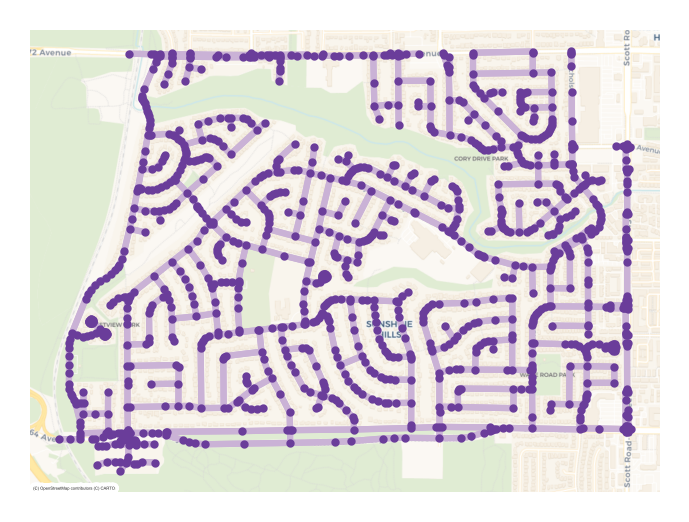

8 12


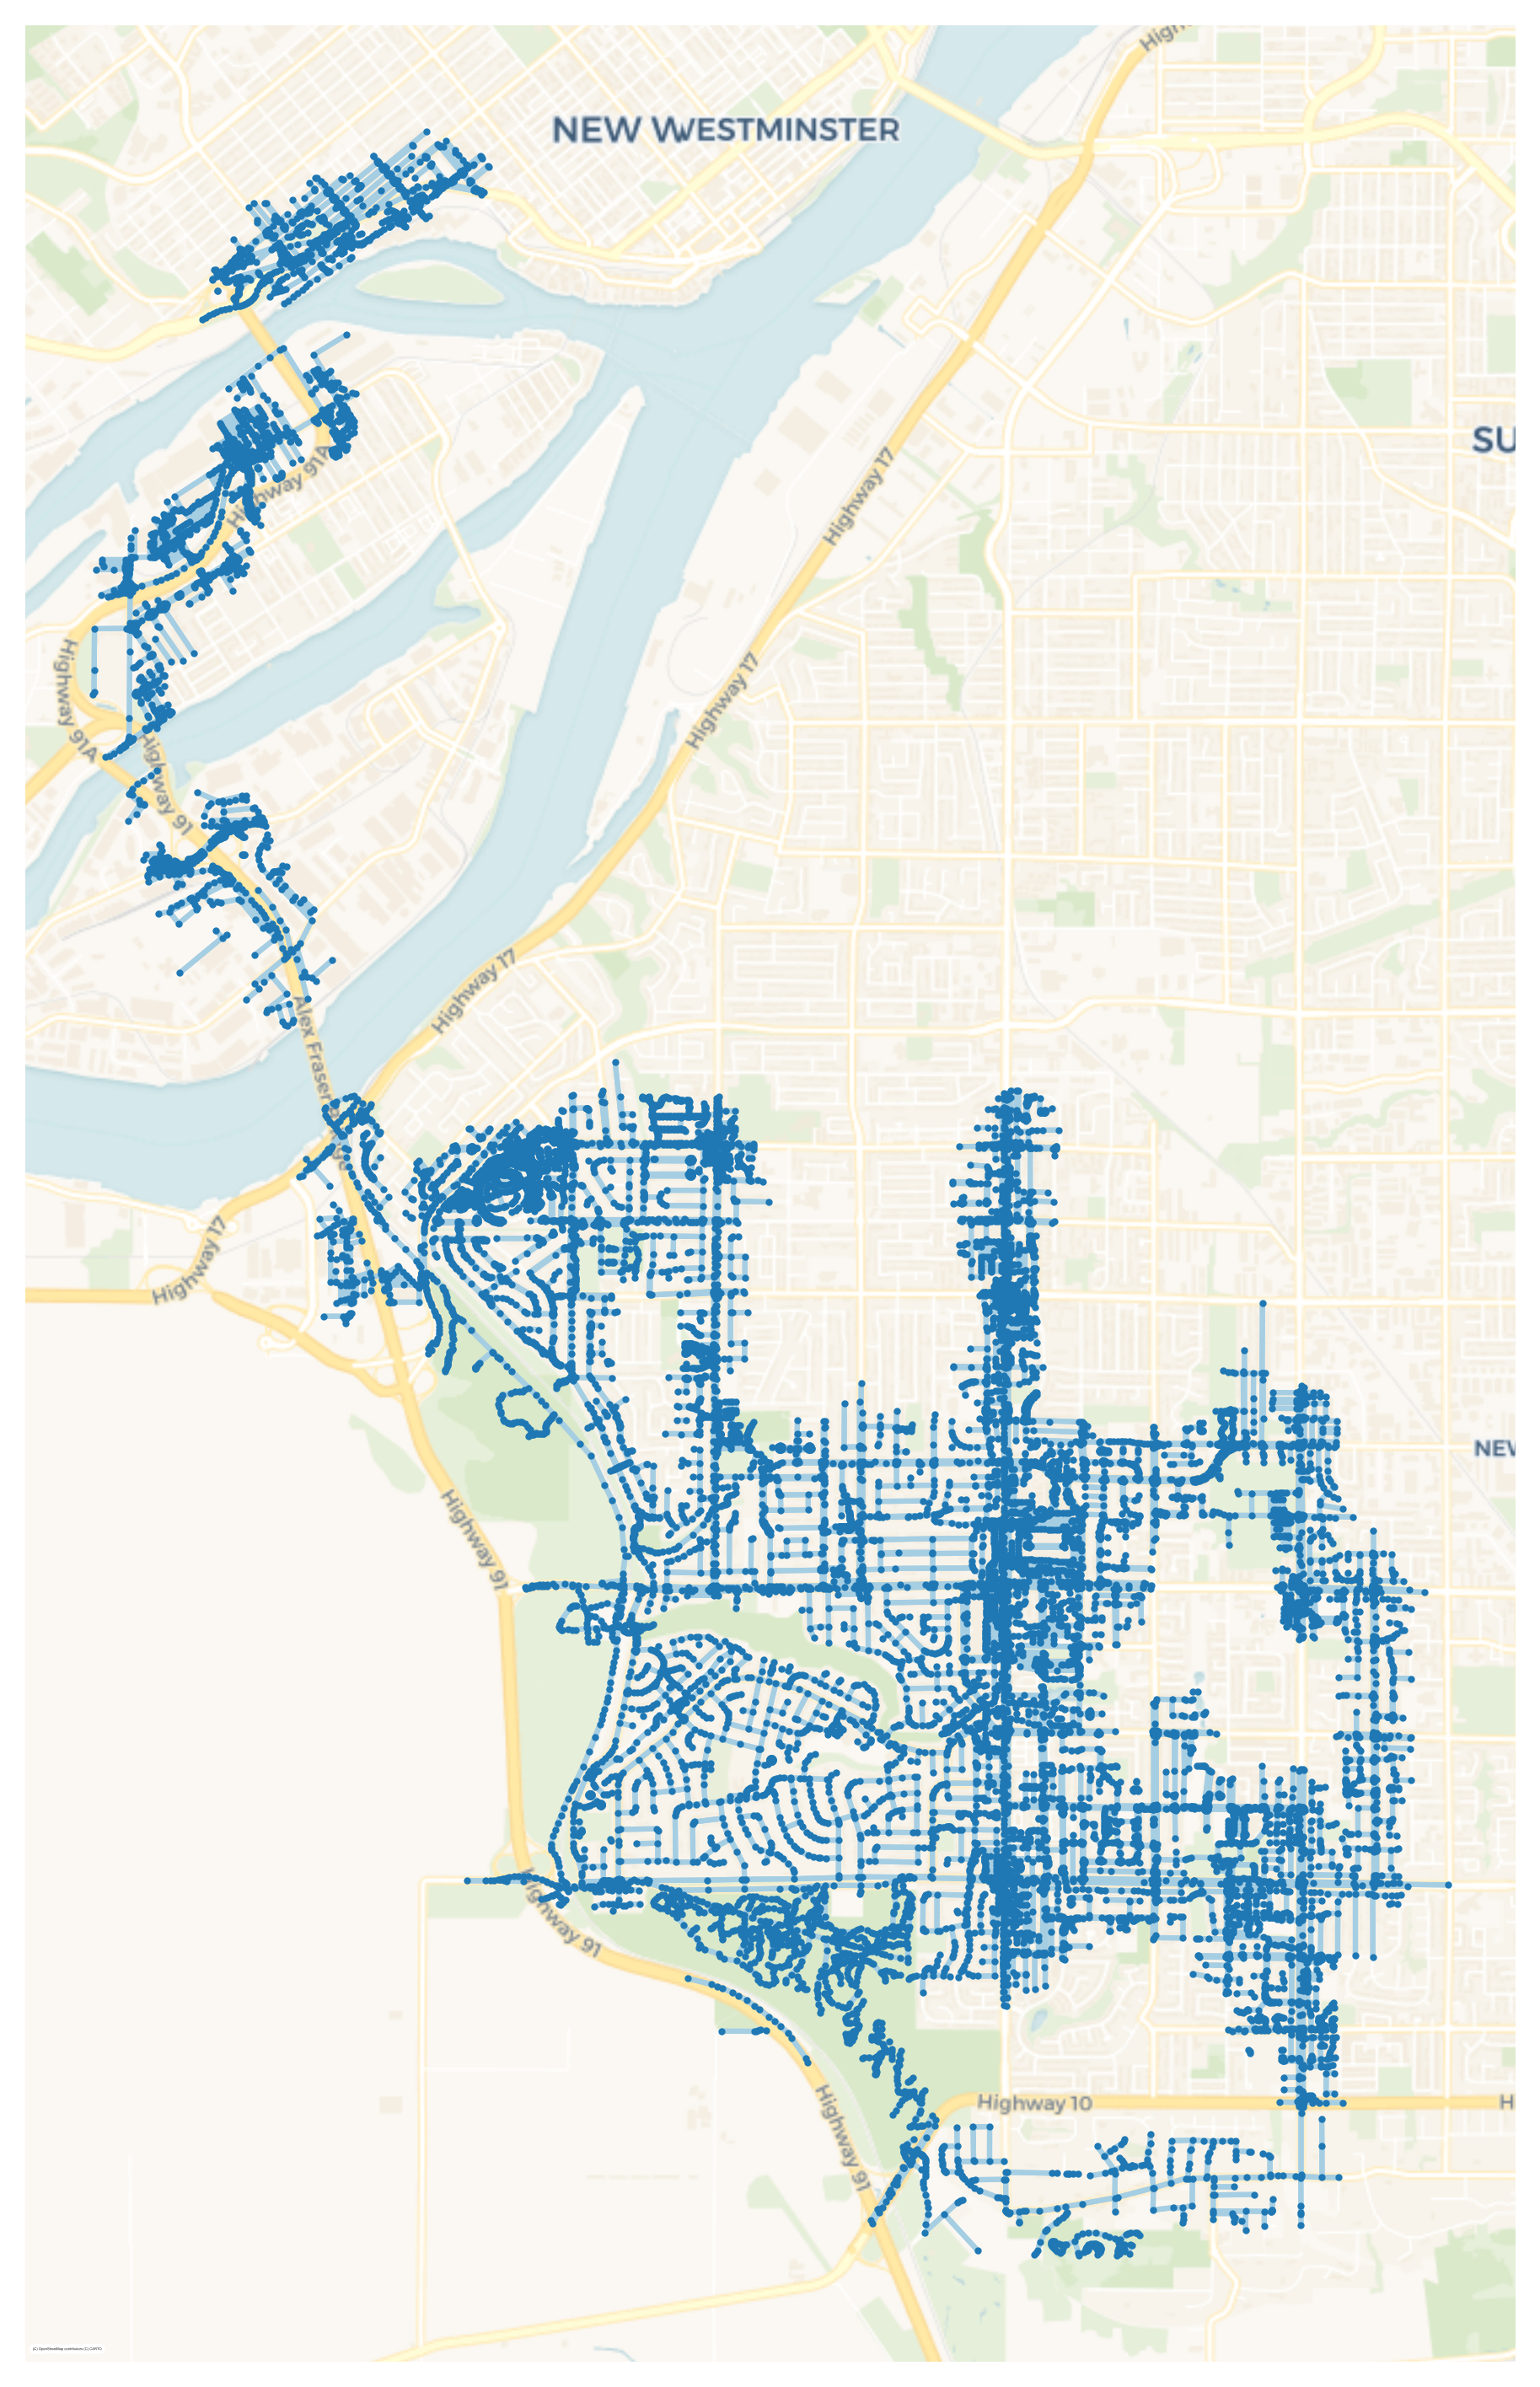

3 2


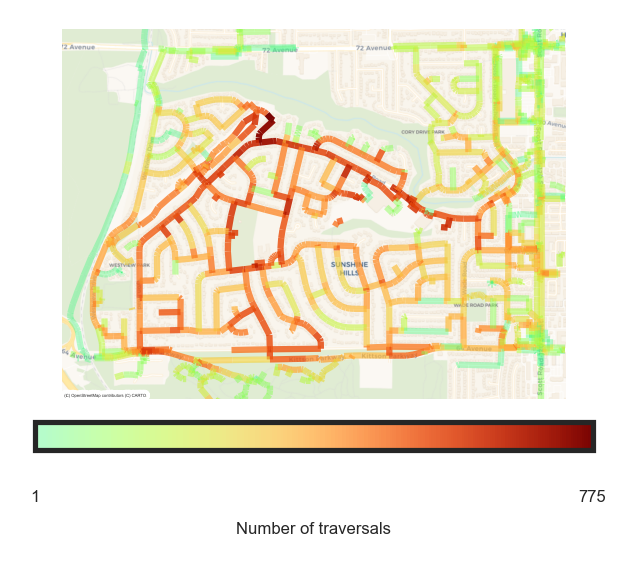

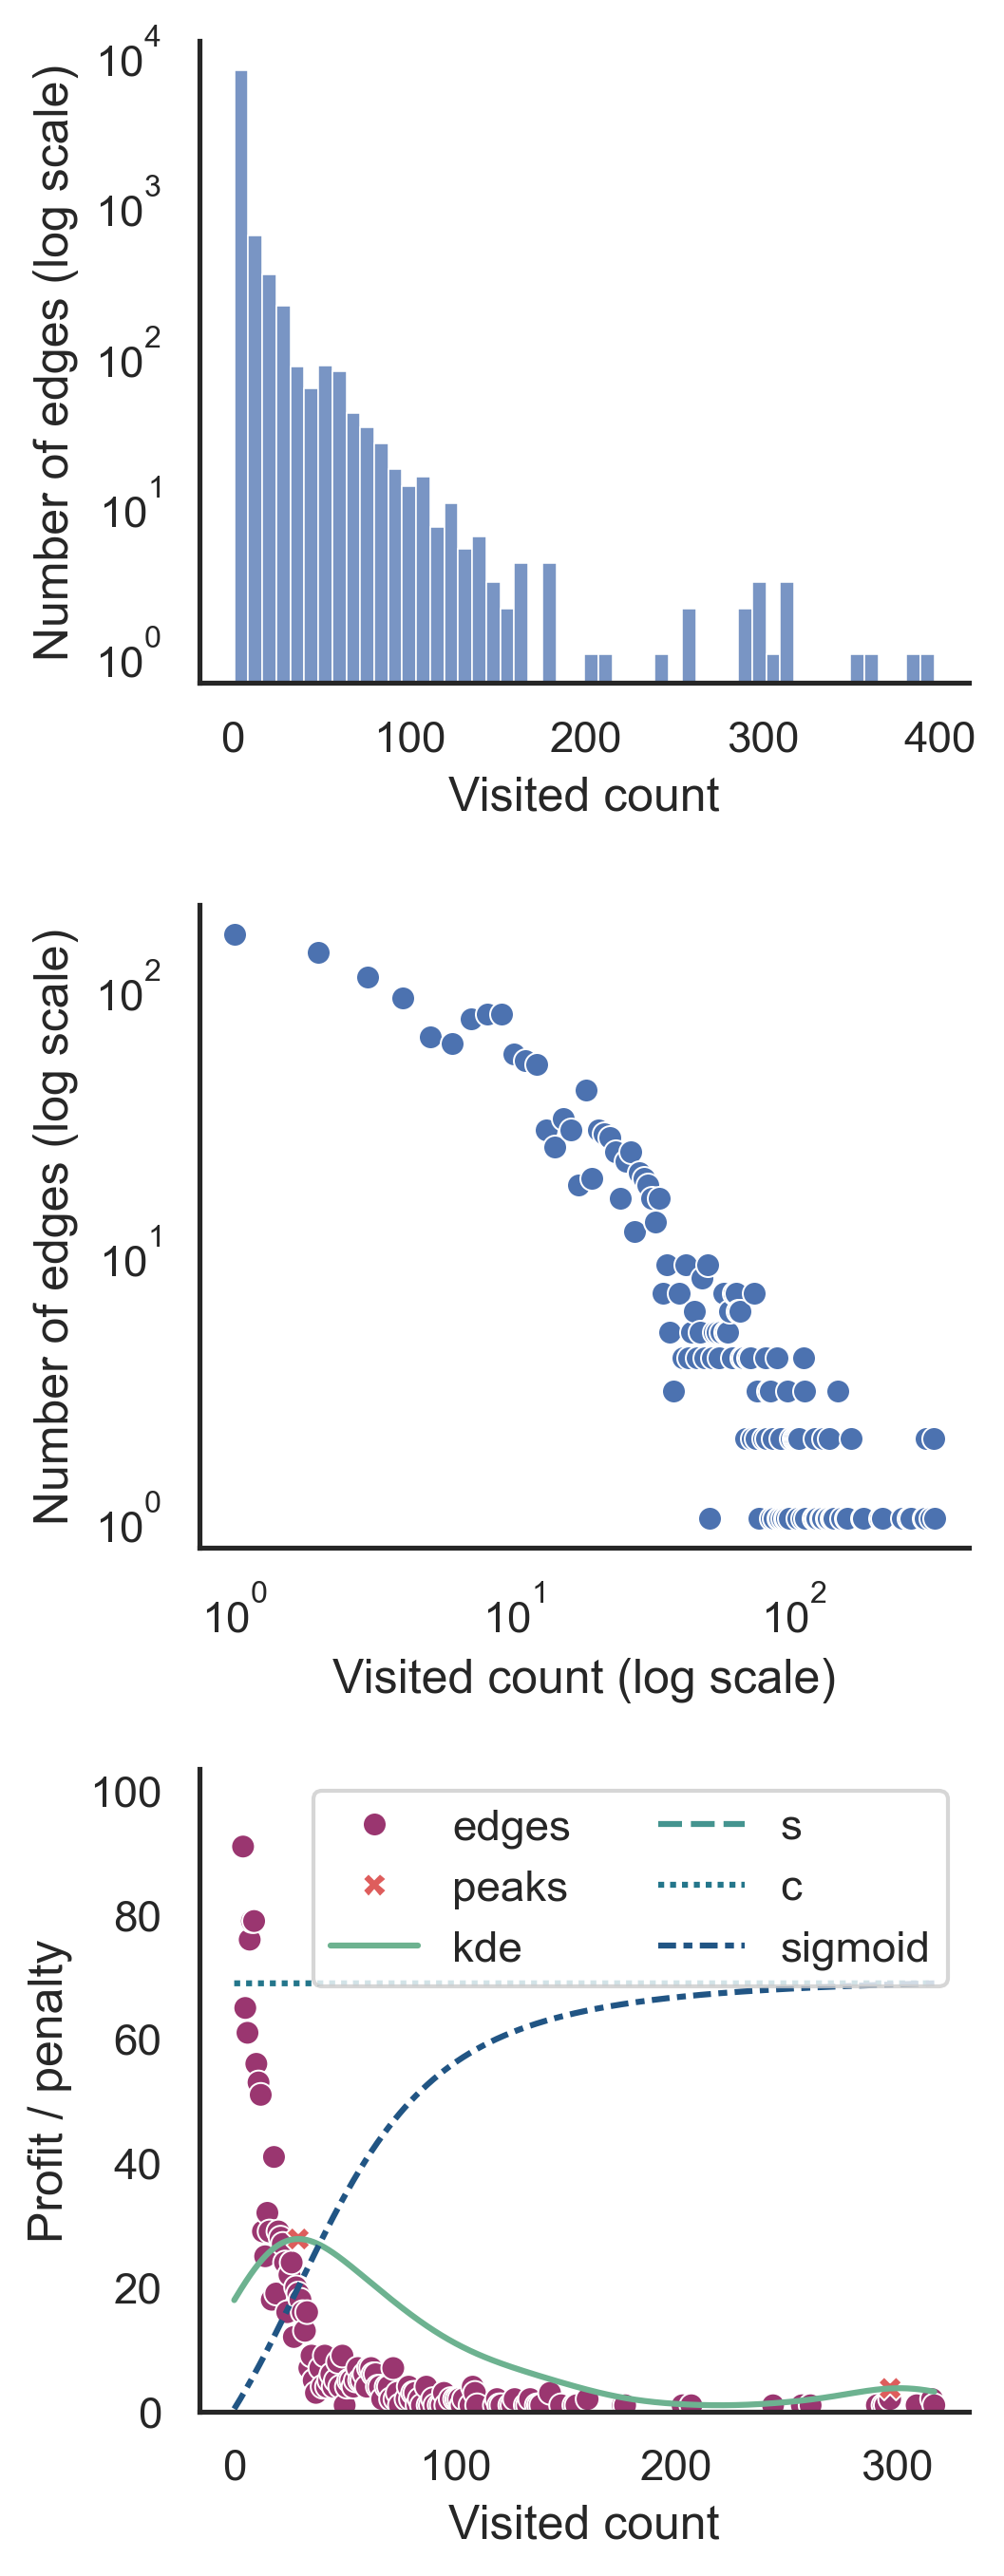

In [35]:
jess_min = InstanceHandler("Sunshine Hills", "jess-min", load_from_files=True)
# jess_min.create_cs_graph()
jess_min.plot("G")
# jess_min.create_routes()
# jess_min.create_composite_graph()
jess_min.plot("C")
# jess_min.add_visited_counts()
jess_min.plot("heatmap")
# jess_min.create_instances(["base"])
jess_min.plot("profit_base")
# jess_min.create_instances(["noderem"])
# jess_min.plot("profit_noderem")

# 4. Instances

In the following section, we describe the size of each instance that we solved using the IP model described above. For our problem, we considered two geographic areas: North Delta, BC (instance-jess) and Toronto, ON (instance-jin). To determine how our model scales with the instance size, we begin solving a smaller instance of North Delta, BC (instance-jess-min) which only considers the neighbourhood Sunshine Hills, which is a subset of North Delta. The size of these instances are presented below.

## 4.1 Graph sizes

`instance-jess-min` has 3015 nodes, 6596 edges, and 67% of G has been run

`instance-jess` has 84,756 nodes, 187,294 edges, and 21% of G has been run

`instance-jin` has 385,229 nodes, 867,782 edges, and 1% of G has been run

## 4.2 Run lengths

Furthermore, we varied the difficulty of the problem by solving for different distances. In our experiments, we tried finding an optimal route of 3 different lengths on each graph. Varying the distances not only helps understand how the model performs as the problem becomes harder (by finding longer routes), but also how it performs in more practical scenarios, ie. when the user wants to train a different distance. The lengths that we used to test the model are presented below: 

* `5K`
* `10K`
* `15K`

# 5. Results

## 5.1 Experimental setup

The baseline IP model was tested on 3 instances: instance-jess, instance-jess-min and instance-jin. Each test consisted of finding an optimal route in each graph for total distances of 5km, 10km, and 15km. For each test, a time limit of 1800s was given and were ran on a Windows 11 copmuter with an Intel i7-11700  @ 2.50GHz processor and 32 GB of RAM. 

In each experiment, the current best bound, the current best objective value, and the solver runtime were recorded at each node. These results can show the gap between the bound and objective value as it searches for the optimal solution. In addition to looking at the gap, we recorded the node count for each instance to understand how the search space may scale with the problem size and finally, we present a map of the route for each instance if a solution was found. 

## 5.2 Experimental results

The graphs of the bounds and objective values from solving each instance are presented below:

<center><img src='https://github.com/jingng/MIE1603-Project/blob/main/images/baseline_all.png?raw=true'></center>

Unfortunately, the model could not solve any of the instances to optimality. However, for the instance-jess-min graph, the model was able to find a feasible solution within the alloted time and improve upon the first feasible solution. It's interesting to note that the model was not able to find a feasible 10km run for instance-jess, but was able to find a near optimal 15km run for the same instance. This result should be tested on other graphs of the same size to see if it is an anomaly or the model consistently fails to find its first feasible 10km run. 

The model struggled with finding a feasible solution to instance-jin. This graph is a considerably larger problem instance and the results show that the model would require longer runtime to not only solve the instance but find a feasible solution. Cities such as Toronto have much greater number of edges, which increases the number of runnable paths and in total, the search space for the solution is much larger. Therefore, we can conclude that the model scales poorly as the size of the problem instances grow exponentially. 

Furthermore, the MIP gap and the node count are summarized in the table below. If the model failed to find a feasible solution in the time given, the gap is undefined and denoted with a '-'. We can observe that we obtain a lower final gap with higher distances. This may be because, smaller distances restrict the radius in which we can run and if there are no, or very few, profitable edges within this radius, the model may find a poor first feasible solution. On the other hand, larger distances allow us to run further away if we are within an area of unprofitable edges, and direct us to a cluster of profitable arcs that was previously unreachable. Therfore, the model can find a much better feasible solution much faster, which leads to a smaller final mip gap. 

<center><img src='https://github.com/jingng/MIE1603-Project/blob/main/images/results_table.png?raw=true/'></center>

Finally, we present the final routes that the model obtained on the instance-jess-min graph. 

<div align="center">
  5km Route
</div>
<center><img src='https://github.com/jingng/MIE1603-Project/blob/main/images/5km_route.png?raw=true'/></center>
<div align="center">
  10km Route
</div>
<center><img src='https://github.com/jingng/MIE1603-Project/blob/main/images/10km_route.png?raw=true'/></center>
<div align="center">
  15km Route
</div>
<center><img src='https://github.com/jingng/MIE1603-Project/blob/main/images/15km_route.png?raw=true'/></center>

# 6. Improvements

The improvement approaches we tried fell into two categories: graph pre-processing and branch-and-bound adjustments.

Our first graph pre-processing "improvement" was so critically important that we ended up including it our base model. This was the insight that we only need to consider nodes that are within $T_{\max}$ distance from our starting node. Without this graph truncation, even our smallest instances failed to find a feasible solution within 60 minutes.

## 6.1 Interior node removal

In a similar vein to graph truncation, we reduced the graph size by removing any nodes that were not intersection or leaf nodes and merging their edges. The code for this improvement is given in section 3.4 along with the rest of the instance creation code.

The table below shows the difference that removing the interior nodes made on the problem sizes, for both node count and edge count. 

<center><img src='https://github.com/jingng/MIE1603-Project/blob/main/images/interior_results.png?raw=true' /></center>

We focused on the instance-jess-min problem instance to see if removing the interior nodes improved the model. To compare, we plotted the MIP gap obtained by the model with the original data instance-jess-min and the data with interior nodes removed. The plot is presented below:

<center><img src="https://github.com/jingng/MIE1603-Project/blob/main/images/mip_gap_rem.png?raw=true" alt="image info" /></center>

We can observe that removing the interior nodes had a great impact on improving the model gap, however it was stil not able to solve each instance to optimality. The data pre-processing also improved the time required to find the first feasible solution. 

## 6.2 Branch-and-bound adjustments

The improvement approaches in this section were directly inspired by the branch-and-cut algorithm for the OARP from Archetti et al. [[1](#oarp)]. These approaches include replacing the distance budget lower bound constraint with an additional term in the objective function that penalizes the violation of the constraint, a heuristic to find a lower bound, and modifying the branching priority and strategy. Unfortunately, none of them actually yielded improved results. We have several theories as to why this may be the case.

First, as mentioned earlier, there are several important structural differences between the OARP and our RRP. In particular, the required arcs in the OARP set a lower bound on the total tour distance. Since we lack required arcs, we had to explicitly set a lower bound as a constraint. This meant that the lower bound heuristic which usually returns a feasible solution for the OARP in fact is rarely (never in empirical tests) able to find a feasible solution for the RRP. When we tried relaxing and penalizing the lower bound constraint in order to be able to use this heuristic, empirical tests did not yield a penalty large enough to enforce the constraint.

Second, many of the heuristics that Archetti et al. introduced are computationally expensive. For example, the lower bound solution requires solving a min cost flow problem, while the connectivity cut (which we implmented but which performed so poorly we don't include it here) requires finding a minimum cut for (nearly) every $(0, y_{ij} > 0)$ pair in the LP relaxation. In fact, the heuristics are so computationally expensive that Archetti et al. were strategic about at which MIP nodes they were useed&mdash;that is, they were *only just* worth it for the OARP. For our RRP, they were too computationally expensive relative to their performance gain.

Leading on from this, the third reason we believe these strategies were less effective for us is that Archetti et al. wrote their paper in 2016 and solvers have improved significantly over that time. This means that the tuning approaches (such as setting branching priority) that worked for them were less likely to be successful for us, since solvers are now much better at setting intelligent defaults.

Finally, the complexity of our model formulation (two levels of binary variables) may mean that these kind of heuristic approaches are less effective. One avenue for future work is to explore model reformulations that have a more exploitable problem structure.

The remainder of this section provides the code for these improvements, followed by a discussion of our experimental results.

### 6.2.1 Penalizing the lower bound constraint

In [ ]:
# Penalty Constraint Model

visited = {edge: C.edges[edge]["visited"] for edge in C.edges}
profit = {edge: C.edges[edge]["profit"] for edge in C.edges}
penalty = {edge: C.edges[edge]["penalty"] for edge in C.edges}
violation_penalty = max(visited.values())

edges, lengths = gp.multidict({edge: C.edges[edge]["length"] for edge in C.edges})

m = gp.Model("mp")

# Old Variables
print("adding variables...")
x = m.addVars(
    edges, name="traversed", vtype=GRB.INTEGER
)  # number of times arc (i,j) is traversed
y = m.addVars(
    edges, name="run", vtype=GRB.BINARY
)  # arc (i,j) is chosen to be ran, {0,1}
z = m.addVars(
    {(i, j) for i, j in edges if i < j}, name="profitable_route", vtype=GRB.BINARY
)

# New Variable
v = m.addVar(lb=0, ub=time_limit, name="violation", vtype=GRB.CONTINUOUS)

# ... Same Constraints as previously

# New Objective Function
m.setObjective(
    z.prod(profit) - y.prod(penalty) - x.prod(visited) - v * violation_penalty,
    GRB.MAXIMIZE,
)

### 6.2.2 Lower bound heuristic

In [ ]:
def get_lower_bound(relaxation_sol, edges, int_tol):
    new_solution = relaxation_sol

    # Create solution graph
    G = nx.DiGraph()

    for edge in edges:
        i, j = edge
        G.add_edge(i, j, visited=relaxation_sol["x"][edge])

    H = G.copy()

    # Remove all edges from H where visited is an integer number, otherwise retain only fractional part of visited
    for i, j in G.edges:
        if abs(H[i][j]["visited"] - math.floor(H[i][j]["visited"] + 0.5)) <= int_tol:
            H.remove_edge(i, j)
        else:
            H[i][j]["visited"] = H[i][j]["visited"] % 1

    # Set demand equal to excess visited at node
    for node in H.nodes:
        in_edges = H.in_edges(node)
        out_edges = H.out_edges(node)

        H.nodes[node]["demand"] = sum(
            H.edges[edge]["visited"] for edge in out_edges
        ) - sum(H.edges[edge]["visited"] for edge in in_edges)

    # Set of nodes where demand != 0
    demand_nodes = {
        node: H.nodes[node]["demand"]
        for node in H
        if abs(H.nodes[node]["demand"] - math.floor(H.nodes[node]["demand"] + 0.5))
        > int_tol
    }

    if len(demand_nodes) == 0:
        # set x = int(x)
        new_solution["x"] = {
            edge: int(relaxation_sol["x"][edge]) for edge in relaxation_sol["x"]
        }
    elif len(demand_nodes) < 10:
        # calculate min cost flow and set x from that
        nx.set_node_attributes(G, 0, "demand")
        nx.set_node_attributes(G, demand_nodes, "demand")
        print(sum(demand_nodes.values()))
        flow = nx.min_cost_flow(G, weight="visited")
        for u, v in G.edges:
            if u in flow and v in flow[u]:
                new_solution["x"][(u, v)] = flow[u][v]
            else:
                new_solution["x"][(u, v)] = 0
    else:  # probably not feasible, so return
        return

    # set y and z based on x
    new_solution["y"] = {
        edge: 1 if new_solution["x"][edge] > 0 else 0 for edge in relaxation_sol["y"]
    }
    new_solution["z"] = {
        (i, j): 1
        if new_solution["y"][(i, j)] == 1 or new_solution["y"][(j, i)] == 1
        else 0
        for i, j in relaxation_sol["z"]
    }

    return new_solution


def callback(model, where):
    if where == GRB.Callback.MIPNODE:
        time = model.cbGet(GRB.Callback.RUNTIME)
        obj = model.cbGet(GRB.Callback.MIPNODE_OBJBST)
        bound = model.cbGet(GRB.Callback.MIPNODE_OBJBND)
        node_count = model.cbGet(GRB.Callback.MIPNODE_NODCNT)

        model._data.append((time, obj, bound, node_count))

    # Removed SEC for simplification

    if (
        where == GRB.Callback.MIPNODE
        and model.cbGet(GRB.Callback.MIPNODE_STATUS) == GRB.OPTIMAL
    ):
        node_count = model.cbGet(GRB.Callback.MIPNODE_NODCNT)

        if (
            node_count <= 10
            or (node_count <= 50 and node_count % 2 == 0)
            or node_count % 10 == 0
        ):
            # relaxation_sol = model.cbGetNodeRel(model._x)
            relaxation_sol = {
                "x": {
                    edge: model.cbGetNodeRel(model._x[edge]) for edge in model._edges
                },
                "y": {
                    edge: model.cbGetNodeRel(model._y[edge]) for edge in model._edges
                },
                "z": {
                    (i, j): model.cbGetNodeRel(model._z[(i, j)])
                    for i, j in model._edges
                    if i < j
                },
            }
            new_solution = get_lower_bound(
                relaxation_sol, model._edges, model.Params.IntFeasTol
            )
            if new_solution is None:
                return
            new_sol_arr = np.zeros(len(model.getVars()))
            for edge, val in new_solution["x"].items():
                new_sol_arr[model._x[edge].index] = val
            for edge, val in new_solution["y"].items():
                new_sol_arr[model._y[edge].index] = val
            for edge, val in new_solution["z"].items():
                new_sol_arr[model._z[edge].index] = val
            lb_constr = model.getConstrByName("total_length_lb")
            new_sol_arr[model._v.index] = lb_constr.rhs - sum(
                new_sol_arr[model.getRow(lb_constr).getVar(idx).index]
                * model.getRow(lb_constr).getCoeff(idx)
                for idx in range(model.getRow(lb_constr).size())
            )

            # Objective value of current solution
            current_obj_val = model.cbGet(GRB.Callback.MIPNODE_OBJBST)

            objective = model.getObjective()
            obj_val = sum(
                new_sol_arr[objective.getVar(idx).index] * objective.getCoeff(idx)
                for idx in range(objective.size())
            )  # Calculate objective value for new solution

            # If your feasible solution is better than gurobi's, replace the solution
            if obj_val > current_obj_val:
                model.cbSetSolution(model.getVars(), new_sol_arr)


### 6.2.3 Branching strategy and priority

In [ ]:
m = gp.Model("mp")

# Variables
x = m.addVars(
    edges, name="traversed", vtype=GRB.INTEGER
)  # number of times arc (i,j) is traversed
y = m.addVars(
    edges, name="run", vtype=GRB.BINARY
)  # arc (i,j) is chosen to be ran, {0,1}
z = m.addVars(
    {(i, j) for i, j in edges if i < j}, name="profitable_route", vtype=GRB.BINARY
)

# Setting Branching Priority
# Variables with larger values will take priority over those with smaller values

z.BranchPriority = 100
y.BranchPriority = 75
x.BranchPriority = 50

## 6.3 Experimental results

We tested these three improvements under similar settings as to the baseline model, where we tested each model on instance-jess-min, instance-jess, and instance-jin graphs for lengths 5km, 10km, and 15km with a time limit of 1800s. Unfortunately, in all instances, it was unable to find a feasible solution within the given time.

# 7. Conclusion

Even though only one of our speed-up elements improved the model and our models didn't solve to optimality, we are content with obtaining feasible routes that are runnable and reasonable. The nature of the problem is large and was definitely challenging; therefore, the IP model that we have developed is a good start to solving the RRP problem and definitely has room for improvements. Some future steps for this project include using undirected graphs as problem instances. This reduces the number of variables and constraints, which can greatly improve the model's performance. Another avenue to explore is formulating the model differently, in a manner that is more tractable and more succinct in terms of variables and constraints. Finally, we saw that the model was not able to scale to solve large cities such as Toronto, but a strategy to overcome this is to consider small neighborhoods, similar to how we took a subset of North Delta as instance-jess-min which proved to be much easier to solve. 

# Declaration of Contribution

Jessica and Jin both agree that each team member has roughly contributed equally to the overall project. Further, Jin would like to thank Jessica for spending way too much time on what we thought would be the relatively easy data pre-processing, and Jessica would like to thank Jin for spending way too many weekends at the lab figuring out why our models couldn't even find a feasible solution. This project truly required a team effort to tackle.

# References

<a id="oarp"></a>[1] Archetti, C., Corberán, A., Plana, I., Sanchis, J.M., & Speranza A.G. (2016). A branch-and-cut algorithm for the Orienteering Arc Routing Problem. *Computers & Operations Research, 66,* 95-104. https://doi.org/10.1016/j.cor.2015.08.003

<a id="citystrides"></a>[2] Chevalier, J. CityStrides. https://citystrides.com/

<a id="csquery"></a>[3] CityStrides (2025). *CityStrides Street Query* (January 6, 2025) [Data set]. https://docs.google.com/spreadsheets/d/1dbj5giwBhCG-jWmokCnQOJhkIEE132FvXVyrvDL7tSU/

<a id="arcrouting"></a>[4] Corberán Á., Eglese R., Hasle G., Plana I., Sanchis J.M. (2021) Arc routing problems: A review of the past, present, and future. *Networks, 77,* 88–115. https://doi.org/10.1002/net.21965

<a id="mapmatch"></a>[5] Huang, Z., Qiao, S., Han, N., Yuan, C.-a., Song, X. & Xiao, Y. (2021), Survey on vehicle map matching techniques. *CAAI Transactions on Intelligence Technology, 6,* 55-71. https://doi-org/10.1049/cit2.12030

<a id="orienteering"></a>[6] Gunawan, A., Lau, H.C., & Vansteenwegen, P. (2016). Orienteering problem: A survey of recent variants, solution approaches and applications. *European Journal of Operational Research, 255(2),* 315-332. https://doi.org/10.1016/j.ejor.2016.04.059

<a id="osmbasics"></a>[7] *OSM basics.* (2022, March 26). CityStrides Community. Retrieved March 25, 2025, from https://community.citystrides.com/t/osm-basics/21283

<a id="pytrack"></a>[8] Tortora, M., Cordelli, E., & Soda, P. (2022). PyTrack: a Map-Matching-based Python Toolbox for Vehicle Trajectory Reconstruction. *IEEE Access, 10,* 112713–112720. https://doi.org/10.1109/ACCESS.2022.3216565

<a id=wandrer></a>[9] Wandrer. https://wandrer.earth/

<a id="way"></a>[10] *Way.* (2025, March 18). OpenStreetMap Wiki. Retrieved March 25, 2025, from https://wiki.openstreetmap.org/wiki/Way